# 대전광역시 상권 변화 시계열 분석
2024~2026년 지역·업종별 상가 수 변화. 위에서 아래로 모두 실행하면 가공 CSV와 그림을 다시 생성합니다.
원본은 읽기만 합니다. `period`의 1일은 파일명 기준월을 표현하기 위한 값이며 실제 조사일을 뜻하지 않습니다.
2025년 10월은 별도 관측입니다. 2025년 9월로 바꾸거나 결측 분기를 보간하지 않습니다.

첨부 837→247 연계표로 전 기간을 정규화합니다. 원본이 이미 최신 코드이면 유지하고, 구 코드의 1:N 분리는 상위 수준까지만 확정합니다. 정규화 전후와 업소번호 집합 변화를 비교합니다.

## 1. 라이브러리와 실행 환경
분석은 pandas·numpy·matplotlib, 검증은 표준 라이브러리 csv와 assert를 사용합니다.

In [1]:
from pathlib import Path
from collections import Counter
import csv
import hashlib
import importlib.metadata as metadata
import json
import re
import sys
import textwrap

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, ticker
from IPython.display import display, Markdown

ROOT = Path.cwd()
OUT = ROOT / 'data' / 'processed'
IMAGES = ROOT / 'images'
OUT.mkdir(parents=True, exist_ok=True)
IMAGES.mkdir(exist_ok=True)
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
font = next((f for f in ['Malgun Gothic', 'AppleGothic', 'Noto Sans CJK KR', 'NanumGothic'] if f in installed_fonts), None)
if font is None:
    raise RuntimeError('한글 글꼴이 필요합니다. 맑은 고딕 또는 Noto Sans CJK KR을 설치한 뒤 커널을 다시 시작하세요.')
plt.rcParams.update({'font.family': font, 'axes.unicode_minus': False, 'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})
versions = {name: metadata.version(name) for name in ['pandas', 'numpy', 'matplotlib', 'notebook', 'nbformat', 'nbclient', 'ipykernel', 'openpyxl']}
print('파이썬:', sys.version.split()[0], '한글 글꼴:', font)
display(pd.Series(versions, name='실행 버전'))

파이썬: 3.14.6 한글 글꼴: Malgun Gothic


pandas         3.0.5
numpy          2.5.2
matplotlib    3.11.1
notebook       7.6.2
nbformat      5.11.1
nbclient      0.11.0
ipykernel      7.3.0
openpyxl       3.1.5
Name: 실행 버전, dtype: str

## 2. 원본 자동 탐색과 기준월 추출
`data/raw` 또는 사용자가 제공한 기존 원본 폴더 중 한 곳에만 CSV를 둡니다. 동일 시점이 중복되면 중단합니다.

In [2]:
source_dirs = [ROOT / 'data' / 'raw', ROOT / '00. 대전 상권 데이터']
files = sorted(p for folder in source_dirs if folder.exists() for p in folder.glob('*.csv'))
assert files, '원본 CSV가 없습니다. README의 수집 방법을 확인하세요.'
manifest = []
for path in files:
    match = re.search(r'_(20\d{4})\.csv$', path.name)
    if not match:
        raise ValueError(f'기준월을 해석할 수 없는 파일명: {path.name}')
    period = pd.to_datetime(match.group(1), format='%Y%m')
    assert 2024 <= period.year <= 2026, f'분석 범위를 벗어난 파일: {path.name}'
    manifest.append({'file': path.name, 'path': path, 'period': period,
                     'sha256': hashlib.sha256(path.read_bytes()).hexdigest()})
manifest = pd.DataFrame(manifest).sort_values('period').reset_index(drop=True)
assert manifest.period.is_unique, '같은 기준월의 원본 파일이 여러 개입니다.'
display(manifest[['file', 'period']])

,file,period
0,소상공인시장진흥공단_상가(상권)정보_대전_202403.csv,2024-03-01
1,소상공인시장진흥공단_상가(상권)정보_대전_202406.csv,2024-06-01
2,소상공인시장진흥공단_상가(상권)정보_대전_202409.csv,2024-09-01
3,소상공인시장진흥공단_상가(상권)정보_대전_202412.csv,2024-12-01
4,소상공인시장진흥공단_상가(상권)정보_대전_202503.csv,2025-03-01
5,소상공인시장진흥공단_상가(상권)정보_대전_202506.csv,2025-06-01
6,소상공인시장진흥공단_상가(상권)정보_대전_202510.csv,2025-10-01
7,소상공인시장진흥공단_상가(상권)정보_대전_202512.csv,2025-12-01
8,소상공인시장진흥공단_상가(상권)정보_대전_202603.csv,2026-03-01
9,소상공인시장진흥공단_상가(상권)정보_대전_202606.csv,2026-06-01


## 2.1 첨부 837→247 연계표 읽기
1번 시트의 코드·명칭을 정규화 기준으로, 3번 시트의 구→신 관계와 비고를 매핑 근거로 사용합니다.
현재 247 코드와 구 837 코드의 집합이 서로 겹치지 않음을 검사합니다. 최신 코드에 구 체계를 다시 적용하지 않습니다.
비고에 분리라고 쓰이지 않은 경우도 실제 후보가 여러 개라면 1:N으로 처리합니다.

In [3]:
from classification import read_crosswalk, build_mapping, normalize_records, aggregate_level
from test_mapping import test_mapping

crosswalk_path = next(p for p in ROOT.glob('*.xlsx') if '업종분류' in p.name and '연계표' in p.name)
crosswalk_hash = hashlib.sha256(crosswalk_path.read_bytes()).hexdigest()
taxonomy, original_edges, edges = read_crosswalk(crosswalk_path)
mapping = build_mapping(taxonomy, edges)
major_names = taxonomy.set_index('major_code').major_name.to_dict()
crosswalk_summary = original_edges.groupby('crosswalk_type').agg(
    original_rows=('sheet_row', 'size'), old_codes=('old_code', 'nunique'), new_codes=('new_code', 'nunique'))
crosswalk_summary['deduplicated_rows'] = edges.groupby('crosswalk_type').size()
crosswalk_summary = crosswalk_summary.reindex(['유지', '통합', '분리', '제외', '추가']).reset_index()
legacy = mapping.loc[mapping.source_system.eq('837')]
legacy_resolution = legacy.groupby(['mapping_type', 'mapping_confidence']).size().rename('old_code_count').reset_index()
added_codes = set(edges.loc[edges.crosswalk_type.eq('추가'), 'new_code'])
with_ancestors = set(edges.loc[edges.old_code.notna(), 'new_code'].dropna())
added_only_codes = added_codes - with_ancestors
test_mapping()
display(crosswalk_summary)
display(legacy_resolution)
display(legacy.loc[legacy.mapping_type.eq('분리'), ['source_small_code', 'candidate_small_codes', 'crosswalk_types', 'mapping_confidence']])

검증 통과: 최신 코드 유지, 통합, 1:N 분리, 상위 분류, 제외, 추가 업종 결측, 미매핑


,crosswalk_type,original_rows,old_codes,new_codes,deduplicated_rows
0,유지,80,80,80,80
1,통합,605,601,122,605
2,분리,8,4,8,8
3,제외,156,156,0,156
4,추가,42,0,40,40


,mapping_type,mapping_confidence,old_code_count
0,분리,미확정,2
1,분리,중분류확정,5
2,유지,소분류확정,78
3,제외,제외확정,156
4,통합,소분류확정,596


,source_small_code,candidate_small_codes,crosswalk_types,mapping_confidence
265,F02A05,N10201|N10202|N10203,분리,중분류확정
299,F05A02,N10401|N10402|N10403,분리|통합,중분류확정
376,F14A03,G20301|S20401,분리,미확정
669,O03A01,I10103|I10104,유지|통합,중분류확정
762,Q03A02,I20301|I20399,통합,중분류확정
810,Q07A07,G20507|I21008,유지|통합,미확정
854,Q10A08,I20501|I20599,유지|통합,중분류확정


## 3. 전체 컬럼 로드, 결측·중복·스키마 확인
코드와 식별자는 선행 0을 보존하도록 문자열로 읽습니다. 빈 문자열·공백만 결측으로 처리합니다.
핵심 컬럼 결측, 동일 업소번호에 서로 다른 행, 대전 외 지역은 임의 보정하지 않고 오류를 발생시킵니다.
완전히 같은 중복 행만 하나 남깁니다. 현재 원본에는 이런 중복도 없습니다.

In [4]:
ID = '상가업소번호'
DISTRICT = '시군구명'
CAT = '상권업종대분류명'
MID = '상권업종중분류명'
district_order = ['동구', '중구', '서구', '유성구', '대덕구']
district_codes = {'30110': '동구', '30140': '중구', '30170': '서구', '30200': '유성구', '30230': '대덕구'}
core = [ID, '시도코드', '시도명', '시군구코드', DISTRICT]
for level in ['대', '중', '소']:
    core += [f'상권업종{level}분류코드', f'상권업종{level}분류명']
frames, audits, missing_rows, schema_rows, code_rows, admin_rows = {}, [], [], [], [], []
base_columns = None
for entry in manifest.itertuples():
    frame = pd.read_csv(entry.path, dtype='string', encoding='utf-8-sig', keep_default_na=False)
    frame = frame.apply(lambda col: col.str.strip().replace('', pd.NA))
    assert set(core).issubset(frame.columns), f'필수 컬럼 누락: {entry.file}'
    if base_columns is None:
        base_columns = list(frame.columns)
    raw_rows = len(frame)
    exact_duplicates = int(frame.duplicated().sum())
    duplicate_ids = int(frame[ID].duplicated().sum())
    for col in frame:
        missing_rows.append({'period': entry.period, 'column': col, 'missing_count': int(frame[col].isna().sum()),
                             'missing_pct': float(frame[col].isna().mean() * 100)})
    for position, col in enumerate(frame.columns, 1):
        schema_rows.append({'period': entry.period, 'position': position, 'column': col, 'dtype': str(frame[col].dtype)})
    assert not frame[core].isna().any().any(), f'핵심 컬럼 결측: {entry.file}'
    frame = frame.drop_duplicates()
    assert not frame[ID].duplicated().any(), f'내용이 충돌하는 업소번호 중복: {entry.file}'
    assert frame['시도코드'].eq('30').all() and frame['시도명'].eq('대전광역시').all()
    assert set(frame[DISTRICT]) == set(district_order)
    assert frame['시군구코드'].map(district_codes).eq(frame[DISTRICT]).all()
    for level in ['대', '중', '소']:
        pairs = frame[[f'상권업종{level}분류코드', f'상권업종{level}분류명']].drop_duplicates()
        for code, name in pairs.itertuples(index=False, name=None):
            code_rows.append({'period': entry.period, 'level': level, 'code': code, 'name': name})
    for level, code, name in [('시도', '시도코드', '시도명'), ('시군구', '시군구코드', '시군구명'),
                              ('행정동', '행정동코드', '행정동명'), ('법정동', '법정동코드', '법정동명')]:
        for c, n in frame[[code, name]].drop_duplicates().itertuples(index=False, name=None):
            admin_rows.append({'period': entry.period, 'level': level, 'code': c, 'name': n})
    lon = pd.to_numeric(frame['경도'], errors='coerce')
    lat = pd.to_numeric(frame['위도'], errors='coerce')
    invalid_coordinates = int((~lon.between(-180, 180) | ~lat.between(-90, 90)).sum())
    audits.append({'period': entry.period, 'file': entry.file, 'raw_rows': raw_rows, 'clean_rows': len(frame),
                   'columns': len(frame.columns), 'same_schema': list(frame.columns) == base_columns,
                   'duplicate_ids': duplicate_ids, 'exact_duplicates': exact_duplicates,
                   'core_missing': int(frame[core].isna().sum().sum()), 'invalid_coordinates': invalid_coordinates,
                   'sha256': entry.sha256})
    frame['period'] = entry.period
    # 전체 구조 검사가 끝난 뒤 분석에 필요한 컬럼만 유지해 메모리를 절약합니다.
    frames[entry.period] = frame[list(dict.fromkeys(core + [MID, '행정동코드', '행정동명', '상호명', '도로명주소', 'period']))].copy()

audit = pd.DataFrame(audits)
missing = pd.DataFrame(missing_rows)
schema = pd.DataFrame(schema_rows)
codes = pd.DataFrame(code_rows).sort_values(['period', 'level', 'code'])
admin = pd.DataFrame(admin_rows).sort_values(['period', 'level', 'code'])
display(audit.drop(columns=['sha256']))
display(missing.loc[missing.missing_count.gt(0)].pivot(index='column', columns='period', values='missing_count').fillna(0).astype(int))
print('전체 컬럼:', ', '.join(base_columns))

,period,file,raw_rows,clean_rows,columns,same_schema,duplicate_ids,exact_duplicates,core_missing,invalid_coordinates
0,2024-03-01,소상공인시장진흥공단_상가(상권)정보_대전_202403.csv,72067,72067,39,True,0,0,0,0
1,2024-06-01,소상공인시장진흥공단_상가(상권)정보_대전_202406.csv,70832,70832,39,True,0,0,0,0
2,2024-09-01,소상공인시장진흥공단_상가(상권)정보_대전_202409.csv,68867,68867,39,True,0,0,0,0
3,2024-12-01,소상공인시장진흥공단_상가(상권)정보_대전_202412.csv,80589,80589,39,True,0,0,0,0
4,2025-03-01,소상공인시장진흥공단_상가(상권)정보_대전_202503.csv,77904,77904,39,True,0,0,0,0
5,2025-06-01,소상공인시장진흥공단_상가(상권)정보_대전_202506.csv,77605,77605,39,True,0,0,0,0
6,2025-10-01,소상공인시장진흥공단_상가(상권)정보_대전_202510.csv,78418,78418,39,True,0,0,0,0
7,2025-12-01,소상공인시장진흥공단_상가(상권)정보_대전_202512.csv,78246,78246,39,True,0,0,0,0
8,2026-03-01,소상공인시장진흥공단_상가(상권)정보_대전_202603.csv,78607,78607,39,True,0,0,0,0
9,2026-06-01,소상공인시장진흥공단_상가(상권)정보_대전_202606.csv,80704,80704,39,True,0,0,0,0


period,2024-03-01,2024-06-01,2024-09-01,2024-12-01,2025-03-01,2025-06-01,2025-10-01,2025-12-01,2026-03-01,2026-06-01
column,,,,,,,,,,
건물관리번호,4,4,4,227,0,0,391,384,369,394
건물명,54010,53056,51636,56781,54516,54209,54162,54620,55610,55185
건물본번지,15,15,15,0,0,0,0,0,0,0
건물부번지,60769,59720,58094,68100,65874,65606,66489,66287,66547,68355
도로명코드,15,15,15,0,0,0,0,0,0,0
동정보,72067,70832,68867,80589,77904,77605,72263,78246,78607,80704
지번본번지,0,0,0,0,2,11,13,14,3,3
지번부번지,20065,19714,19121,22971,22325,22199,23360,23353,23434,24037
지점명,69873,68477,66595,69909,67579,67400,68348,68107,68745,69924


전체 컬럼: 상가업소번호, 상호명, 지점명, 상권업종대분류코드, 상권업종대분류명, 상권업종중분류코드, 상권업종중분류명, 상권업종소분류코드, 상권업종소분류명, 표준산업분류코드, 표준산업분류명, 시도코드, 시도명, 시군구코드, 시군구명, 행정동코드, 행정동명, 법정동코드, 법정동명, 지번코드, 대지구분코드, 대지구분명, 지번본번지, 지번부번지, 지번주소, 도로명코드, 도로명, 건물본번지, 건물부번지, 건물관리번호, 건물명, 도로명주소, 구우편번호, 신우편번호, 동정보, 층정보, 호정보, 경도, 위도


## 4. 분류체계와 연속 시점의 업소번호 비교
동일 코드·명칭 집합은 비교 가능성을 높이지만 수집 범위가 같다는 증거는 아닙니다.
등장·소멸은 데이터상 식별자 변화입니다. 창업·폐업으로 해석하지 않습니다.
공통 식별자의 업종·구 변경과, 소멸/등장 집합 사이의 동일 상호·주소도 별도로 검사합니다.

In [5]:
periods = list(frames)
transitions, classification_changes, admin_changes = [], [], []
for previous, current in zip(periods, periods[1:]):
    old = frames[previous].set_index(ID)
    new = frames[current].set_index(ID)
    common = old.index.intersection(new.index)
    appeared = new.index.difference(old.index)
    disappeared = old.index.difference(new.index)
    old_keys = set(old.loc[disappeared, ['상호명', '도로명주소']].dropna().itertuples(index=False, name=None))
    new_keys = set(new.loc[appeared, ['상호명', '도로명주소']].dropna().itertuples(index=False, name=None))
    transitions.append({'previous_period': previous, 'period': current, 'common': len(common),
        'appeared': len(appeared), 'disappeared': len(disappeared), 'net_change': len(new) - len(old),
        'observed_change_pct': (len(new) / len(old) - 1) * 100,
        'turnover_pct': (len(appeared) + len(disappeared)) / len(old) * 100,
        'common_category_changed': int(old.loc[common, CAT].ne(new.loc[common, CAT]).sum()),
        'common_district_changed': int(old.loc[common, DISTRICT].ne(new.loc[common, DISTRICT]).sum()),
        'same_name_address_keys': len(old_keys & new_keys)})
    for level in ['대', '중', '소']:
        old_codes = set(codes.loc[codes.period.eq(previous) & codes.level.eq(level), ['code', 'name']].itertuples(index=False, name=None))
        new_codes = set(codes.loc[codes.period.eq(current) & codes.level.eq(level), ['code', 'name']].itertuples(index=False, name=None))
        classification_changes.append({'period': current, 'level': level, 'added_pairs': len(new_codes - old_codes), 'removed_pairs': len(old_codes - new_codes)})
    for level in ['시도', '시군구', '행정동', '법정동']:
        old_admin = set(admin.loc[admin.period.eq(previous) & admin.level.eq(level), ['code', 'name']].itertuples(index=False, name=None))
        new_admin = set(admin.loc[admin.period.eq(current) & admin.level.eq(level), ['code', 'name']].itertuples(index=False, name=None))
        admin_changes.append({'period': current, 'level': level, 'added_pairs': len(new_admin - old_admin), 'removed_pairs': len(old_admin - new_admin)})
transitions = pd.DataFrame(transitions)
classification_changes = pd.DataFrame(classification_changes)
admin_changes = pd.DataFrame(admin_changes)
display(transitions)
display(classification_changes.groupby('level')[['added_pairs', 'removed_pairs']].sum())
display(admin_changes.groupby('level')[['added_pairs', 'removed_pairs']].sum())

,previous_period,period,common,appeared,disappeared,net_change,observed_change_pct,turnover_pct,common_category_changed,common_district_changed,same_name_address_keys
0,2024-03-01,2024-06-01,69558,1274,2509,-1235,-1.713683,5.249282,0,0,189
1,2024-06-01,2024-09-01,68766,101,2066,-1965,-2.774170,3.059352,0,0,3
2,2024-09-01,2024-12-01,63476,17113,5391,11722,17.021215,32.677480,754,0,1459
3,2024-12-01,2025-03-01,74950,2954,5639,-2685,-3.331720,10.662746,0,0,380
4,2025-03-01,2025-06-01,75032,2573,2872,-299,-0.383806,6.989372,0,0,300
5,2025-06-01,2025-10-01,73704,4714,3901,813,1.047613,11.101089,0,0,1218
6,2025-10-01,2025-12-01,76074,2172,2344,-172,-0.219337,5.758882,0,0,162
7,2025-12-01,2026-03-01,75705,2902,2541,361,0.461365,6.956266,0,0,179
8,2026-03-01,2026-06-01,70458,10246,8149,2097,2.667701,23.401224,20,0,2508


,added_pairs,removed_pairs
level,,
대,0,0
소,0,0
중,0,0


,added_pairs,removed_pairs
level,,
법정동,0,0
시군구,0,0
시도,0,0
행정동,0,0


## 4.1 원본 업소별 정규화와 적용 결과
실제 수행한 변환 유형은 `mapping_type`, 확정 가능한 수준은 `mapping_confidence`에 기록합니다.
현재 247 코드를 유지한 행의 `mapping_type`은 유지입니다. 그 코드의 과거 연계표 유형은 별도 `crosswalk_types`에 보존합니다.
`추가`는 구 코드가 없는 대상 분류의 특성으로도 기록되며, 현재 자료에 직접 관측되면 관측값을 사용합니다.
신뢰도는 확률 점수가 아니라 연계 관계로 확정할 수 있는 분류 수준입니다.

In [6]:
raw_data = pd.concat(frames.values(), ignore_index=True).sort_values(['period', ID], ignore_index=True)
raw_data['source_small_code'] = raw_data['상권업종소분류코드']
normalized = normalize_records(raw_data, mapping)
assert len(normalized) == len(raw_data)
for level, korean in [('major', '대'), ('middle', '중'), ('small', '소')]:
    normalized[f'original_{level}_code'] = normalized[f'상권업종{korean}분류코드']
    normalized[f'original_{level}_name'] = normalized[f'상권업종{korean}분류명']

mapping_audit = normalized.groupby('period').agg(
    raw_rows=(ID, 'size'), unique_source_codes=('source_small_code', 'nunique'),
    latest_rows=('source_system', lambda s: s.eq('247').sum()),
    legacy_rows=('source_system', lambda s: s.eq('837').sum()),
    small_confirmed=('mapping_level', lambda s: s.eq('small').sum()),
    middle_only=('mapping_level', lambda s: s.eq('middle').sum()),
    major_only=('mapping_level', lambda s: s.eq('major').sum()),
    excluded_rows=('mapping_type', lambda s: s.eq('제외').sum()),
    unresolved_rows=('mapping_confidence', lambda s: s.eq('미확정').sum()),
    source_added_rows=('is_added_category', 'sum')).reset_index()
mapping_usage = normalized.groupby(['mapping_type', 'mapping_confidence']).agg(
    store_observations=(ID, 'size'), unique_store_ids=(ID, 'nunique'), source_codes=('source_small_code', 'nunique')).reset_index()
name_changes = []
for level in ['major', 'middle', 'small']:
    for period, group in normalized.groupby('period'):
        name_changed = group[f'original_{level}_name'].ne(group[f'normalized_{level}_name'])
        code_changed = group[f'original_{level}_code'].ne(group[f'normalized_{level}_code'])
        name_changes.append({'period': period, 'level': level, 'name_changed_rows': int(name_changed.sum()),
            'name_changed_codes': int(group.loc[name_changed, f'original_{level}_code'].nunique()),
            'code_changed_rows': int(code_changed.sum())})
name_changes = pd.DataFrame(name_changes)

# 대분류에서 불확정인 행은 분류를 만들어 넣지 않는다. 확정 집계와 소분류별 결측을 별도로 보존한다.
major_panel = aggregate_level(normalized, taxonomy, edges, 'major', ['period', DISTRICT])
small_timeseries = aggregate_level(normalized, taxonomy, edges, 'small', ['period'])
middle_timeseries = aggregate_level(normalized, taxonomy, edges, 'middle', ['period'])
added_history = small_timeseries.loc[small_timeseries.category_code.isin(added_codes)].copy()
added_history['has_legacy_ancestor'] = added_history.category_code.isin(with_ancestors)
added_history['crosswalk_type'] = '추가'
added_history['mapping_type'] = '추가'  # 업소 변환이 아닌, 대상 분류의 연계표 유형이다.
added_history['mapping_confidence'] = np.where(added_history.store_count.notna(), '소분류확정', '과거비교불가')

record_columns = ['period', ID, DISTRICT, 'source_small_code', 'source_system']
record_columns += [f'{prefix}_{level}_{kind}' for prefix in ['original', 'normalized'] for level in ['major', 'middle', 'small'] for kind in ['code', 'name']]
record_columns += ['mapping_type', 'mapping_confidence', 'mapping_level', 'mapping_basis', 'crosswalk_types',
                   'is_added_category', 'candidate_count', 'candidate_small_codes']
normalized[record_columns].to_csv(OUT / 'normalized_store_records.csv.gz', index=False, encoding='utf-8-sig',
    date_format='%Y-%m-%d', compression={'method': 'gzip', 'mtime': 0})

data = normalized.loc[normalized.normalized_major_code.notna()].copy()
for level, korean in [('major', '대'), ('middle', '중'), ('small', '소')]:
    data[f'상권업종{korean}분류코드'] = data[f'normalized_{level}_code']
    data[f'상권업종{korean}분류명'] = data[f'normalized_{level}_name']
display(mapping_audit)
display(mapping_usage)
display(name_changes.groupby('level')[['name_changed_rows', 'code_changed_rows']].sum())

,period,raw_rows,unique_source_codes,latest_rows,legacy_rows,small_confirmed,middle_only,major_only,excluded_rows,unresolved_rows,source_added_rows
0,2024-03-01,72067,246,72067,0,72067,0,0,0,0,3965
1,2024-06-01,70832,246,70832,0,70832,0,0,0,0,3931
2,2024-09-01,68867,246,68867,0,68867,0,0,0,0,3863
3,2024-12-01,80589,246,80589,0,80589,0,0,0,0,5305
4,2025-03-01,77904,246,77904,0,77904,0,0,0,0,5304
5,2025-06-01,77605,246,77605,0,77605,0,0,0,0,5339
6,2025-10-01,78418,246,78418,0,78418,0,0,0,0,5352
7,2025-12-01,78246,246,78246,0,78246,0,0,0,0,5326
8,2026-03-01,78607,246,78607,0,78607,0,0,0,0,5303
9,2026-06-01,80704,246,80704,0,80704,0,0,0,0,5513


,mapping_type,mapping_confidence,store_observations,unique_store_ids,source_codes
0,유지,소분류확정,763839,114542,246


,name_changed_rows,code_changed_rows
level,,
major,763839,0
middle,749139,0
small,2613,0


## 5. 메인 구간 결정과 시계열 병합
사전 탐색에서 2024년 9→12월의 17.02% 급증과 17,113개 식별자 등장이 확인됐습니다.
분류표 변경은 관찰되지 않았으나 수집·정비 영향을 배제할 수 없어 2025년 3월부터를 메인 구간으로 삼습니다.
2026년 6월도 식별자 교체가 커서 주요 성장률에서는 제외하고 민감도 결과로 제시합니다. 이 선택은 공식 변경일 확정이 아닙니다.

메인 성장 비교 구간은 2024년 말 단절 이후인 2025-03부터 업소번호 교체가 커지기 전인 2026-03까지로 정합니다.

In [7]:
MAIN_START = pd.Timestamp('2025-03-01')
END = pd.Timestamp('2026-03-01')
quarter_months = [3, 6, 9, 12]
main_periods = [p for p in periods if MAIN_START <= p <= END and p.month in quarter_months]
assert MAIN_START in periods and END.month in quarter_months
observed = major_panel.groupby('period').store_count.agg(lambda s: s.sum(min_count=len(s))).to_frame()
observed['previous_observation_pct'] = observed.store_count.pct_change(fill_method=None) * 100
month_numbers = observed.index.to_series().dt.year * 12 + observed.index.to_series().dt.month
observed['months_since_previous'] = month_numbers.diff()
quarter_index = pd.date_range(periods[0], END, freq='3MS', name='period')
total = observed[['store_count']].reindex(quarter_index)
total['qoq_pct'] = total.store_count.pct_change(fill_method=None) * 100
total['yoy_pct'] = total.store_count.pct_change(4, fill_method=None) * 100
district = major_panel.groupby(['period', DISTRICT]).store_count.agg(lambda s: s.sum(min_count=len(s))).unstack().reindex(columns=district_order)
category = major_panel.groupby(['period', 'category']).store_count.agg(lambda s: s.sum(min_count=len(s))).unstack().sort_index(axis=1)
panel = major_panel.rename(columns={DISTRICT: 'district'}).copy()

def add_rates(table, group_columns):
    """행 위치가 아닌 정확히 3개월 전·12개월 전의 동일 집계 조합을 참조합니다."""
    result = table.sort_values(['period'] + group_columns).copy()
    for months, label in [(3, 'qoq_pct'), (12, 'yoy_pct')]:
        reference = table[['period'] + group_columns + ['store_count']].copy()
        reference['period'] = reference.period + pd.DateOffset(months=months)
        reference = reference.rename(columns={'store_count': 'baseline'})
        result = result.merge(reference, on=['period'] + group_columns, how='left', validate='one_to_one')
        result[label] = (result.store_count / result.baseline.where(result.baseline.ne(0)) - 1) * 100
        result.loc[~result.period.dt.month.isin(quarter_months), label] = np.nan
        result = result.drop(columns='baseline')
    return result

panel = add_rates(panel, ['district', 'category'])
panel['quarter'] = panel.period.dt.to_period('Q').astype(str)
panel['is_quarter_end_snapshot'] = panel.period.dt.month.isin(quarter_months)
panel['is_main'] = panel.period.between(MAIN_START, END) & panel.is_quarter_end_snapshot
district_long = add_rates(district.rename_axis(columns='district').stack().rename('store_count').reset_index(), ['district'])
category_long = add_rates(category.rename_axis(columns='category').stack().rename('store_count').reset_index(), ['category'])
display(total)
print('원본 행 수:', len(data), '관측월 수:', len(periods), '분기말 수:', total.store_count.notna().sum(), '구·업종 패널:', len(panel))

,store_count,qoq_pct,yoy_pct
period,,,
2024-03-01,72067.0,NaN,NaN
2024-06-01,70832.0,-1.713683,NaN
2024-09-01,68867.0,-2.774170,NaN
2024-12-01,80589.0,17.021215,NaN
2025-03-01,77904.0,-3.331720,8.099407
2025-06-01,77605.0,-0.383806,9.562062
2025-09-01,NaN,NaN,NaN
2025-12-01,78246.0,NaN,-2.907345
2026-03-01,78607.0,0.461365,0.902393


원본 행 수: 763839 관측월 수: 10 분기말 수: 8 구·업종 패널: 500


## 6. 구·업종·구×업종의 기간 증감과 선택적 중분류 분석
절대 증감량은 전체 변화의 기여를, 증감률은 시작 규모에 대한 상대 변화를 보여 줍니다.
두 지표를 함께 사용해 작은 업종의 높은 비율을 과대평가하지 않습니다.

In [8]:
def growth_table(wide, start=MAIN_START, end=END):
    result = pd.DataFrame({'start_count': wide.loc[start], 'end_count': wide.loc[end]})
    result['change'] = result.end_count - result.start_count
    result['growth_pct'] = result.change / result.start_count.where(result.start_count.ne(0)) * 100
    return result.sort_values('change', ascending=False)

district_growth = growth_table(district)
category_growth = growth_table(category)
panel_wide = panel.pivot(index='period', columns=['district', 'category'], values='store_count')
combination_growth = growth_table(panel_wide)
combination_growth['city_category_growth_pct'] = combination_growth.index.get_level_values('category').map(category_growth.growth_pct)
combination_growth['difference_pp'] = combination_growth.growth_pct - combination_growth.city_category_growth_pct
combination_growth['opposite_direction'] = (combination_growth.growth_pct * combination_growth.city_category_growth_pct).lt(0)
selected_category = category_growth.change.abs().idxmax()
middle = data.loc[data[CAT].eq(selected_category)].groupby(['period', MID]).size().unstack(fill_value=0)
middle_growth = growth_table(middle)
sensitivity = pd.DataFrame({'through_202603_pct': category_growth.growth_pct,
                            'through_202606_pct': growth_table(category, end=pd.Timestamp('2026-06-01')).growth_pct})
district_leaders = combination_growth.reset_index().sort_values('change', ascending=False).groupby('district', sort=False).head(1)
category_latest = category_long.loc[category_long.period.eq(END), ['category', 'qoq_pct', 'yoy_pct']]
district_rate_comparison = district_long.loc[district_long.period.gt(MAIN_START) & district_long.qoq_pct.notna()].copy()
district_rate_comparison['city_qoq_pct'] = district_rate_comparison.period.map(total.qoq_pct)
district_rate_comparison['opposite_direction'] = (district_rate_comparison.qoq_pct * district_rate_comparison.city_qoq_pct).lt(0)
display(district_growth)
display(category_growth)
display(combination_growth)
print('절대 증감량이 가장 큰 업종만 중분류 분석:', selected_category)
display(middle_growth)
display(sensitivity)

,start_count,end_count,change,growth_pct
시군구명,,,,
서구,26586,26885,299,1.124652
유성구,18479,18719,240,1.298772
중구,13034,13105,71,0.544729
대덕구,8257,8318,61,0.738767
동구,11548,11580,32,0.277104


,start_count,end_count,change,growth_pct
category,,,,
수리 및 개인 서비스업,10264,10691,427,4.160171
소매업,19853,20184,331,1.667254
교육 서비스업,5274,5542,268,5.081532
부동산업,2547,2797,250,9.815469
보건의료업,1937,1967,30,1.548787
"전문, 과학 및 기술 서비스업",6839,6842,3,0.043866
숙박업,723,719,-4,-0.553250
"예술, 스포츠 및 여가관련 서비스업",3603,3591,-12,-0.333056
"사업시설 관리, 사업 지원 및 임대 서비스업",3203,3119,-84,-2.622541


start_count  end_count  change  growth_pct  \
district category                                                               
서구       수리 및 개인 서비스업                     3553       3756     203    5.713482   
         소매업                              6068       6202     134    2.208306   
유성구      부동산업                              710        837     127   17.887324   
         수리 및 개인 서비스업                     2271       2380     109    4.799648   
         교육 서비스업                          1210       1318     108    8.925620   
서구       교육 서비스업                          2353       2447      94    3.994900   
         부동산업                              938       1000      62    6.609808   
대덕구      소매업                              2187       2242      55    2.514861   
         수리 및 개인 서비스업                     1291       1344      53    4.105345   
유성구      소매업                              4423       4475      52    1.175673   
동구       소매업                              3385       3436      51    1.506647   
         수리 및 개인 서비스업                     1475       1519      44    2.983051   
중구       소매업                              3790       3829      39    1.029024   
대덕구      교육 서비스업                           290        319      29   10.000000   
유성구      전문, 과학 및 기술 서비스업                 1648       1677      29    1.759709   
중구       부동산업                              337        362      25    7.418398   
         교육 서비스업                           823        843      20    2.430134   
서구       보건의료업                             941        960      19    2.019129   
대덕구      부동산업                              201        219      18    8.955224   
중구       수리 및 개인 서비스업                     1674       1692      18    1.075269   
동구       부동산업                              361        379      18    4.986150   
         교육 서비스업                           598        615      17    2.842809   
서구       예술, 스포츠 및 여가관련 서비스업              1238       1253      15    1.211632   
동구       사업시설 관리, 사업 지원 및 임대 서비스업          429        440      11    2.564103   
유성구      보건의료업                             214        223       9    4.205607   
대덕구      전문, 과학 및 기술 서비스업                  585        591       6    1.025641   
동구       보건의료업                             357        361       4    1.120448   
중구       음식점업                             3851       3854       3    0.077902   
유성구      숙박업                               135        138       3    2.222222   
중구       전문, 과학 및 기술 서비스업                  860        863       3    0.348837   
대덕구      보건의료업                              60         62       2    3.333333   
유성구      예술, 스포츠 및 여가관련 서비스업               864        866       2    0.231481   
서구       숙박업                               152        153       1    0.657895   
동구       숙박업                               173        174       1    0.578035   
대덕구      숙박업                                83         80      -3   -3.614458   
중구       예술, 스포츠 및 여가관련 서비스업               556        553      -3   -0.539568   
         보건의료업                             365        361      -4   -1.095890   
         숙박업                               180        174      -6   -3.333333   
대덕구      사업시설 관리, 사업 지원 및 임대 서비스업          351        341     -10   -2.849003   
동구       예술, 스포츠 및 여가관련 서비스업               472        461     -11   -2.330508   
         전문, 과학 및 기술 서비스업                  876        864     -12   -1.369863   
대덕구      예술, 스포츠 및 여가관련 서비스업               473        458     -15   -3.171247   
서구       전문, 과학 및 기술 서비스업                 2870       2847     -23   -0.801394   
중구       사업시설 관리, 사업 지원 및 임대 서비스업          598        574     -24   -4.013378   
서구       사업시설 관리, 사업 지원 및 임대 서비스업         1137       1109     -28   -2.462621   
유성구      사업시설 관리, 사업 지원 및 임대 서비스업          688        655     -33   -4.796512   
대덕구      음식점업                             2736       2662     -74   -2.704678   
동구       음식점업                             3422       3331     -91 

절대 증감량이 가장 큰 업종만 중분류 분석: 음식점업


,start_count,end_count,change,growth_pct
상권업종중분류명,,,,
한식 음식점업,10046,10333,287,2.856858
일식 음식점업,718,757,39,5.431755
서양식 음식점업,629,652,23,3.656598
중식 음식점업,831,837,6,0.722022
구내식당 및 뷔페,206,203,-3,-1.456311
동남아시아 음식점업,149,128,-21,-14.093960
기타 간이 음식점업,4842,4599,-243,-5.018587
비알코올 음료점업,3932,3637,-295,-7.502543
주점업,2308,2009,-299,-12.954939


,through_202603_pct,through_202606_pct
category,,
교육 서비스업,5.081532,2.370118
보건의료업,1.548787,0.361384
부동산업,9.815469,10.051040
"사업시설 관리, 사업 지원 및 임대 서비스업",-2.622541,9.491102
소매업,1.667254,1.818365
수리 및 개인 서비스업,4.160171,7.063523
숙박업,-0.553250,25.034578
"예술, 스포츠 및 여가관련 서비스업",-0.333056,2.386900
음식점업,-2.138540,0.798783


## 6.1 재분류 전후 비교와 2024년 말 변화 분해
같은 원본을 기존 분류로 집계한 결과와 최신 코드 집계 결과를 대조합니다. 기존 제출 패널도 별도로 보존해 비교합니다.
업종별 순변화를 등장·소멸 업소번호의 차이와 유지 업소의 업종 이동으로 분해합니다.
이 등식은 데이터상 변화의 분해이며, 수집 확대와 실제 개폐업을 구분하는 인과 추정은 아닙니다.

In [9]:
raw_major = raw_data.groupby(['period', '상권업종대분류코드']).size().rename('before_count').reset_index().rename(columns={'상권업종대분류코드': 'category_code'})
after_major = major_panel.groupby(['period', 'category_code'], as_index=False).agg(after_count=('store_count', lambda s: s.sum(min_count=len(s))))
normalization_comparison = raw_major.merge(after_major, on=['period', 'category_code'], how='outer', validate='one_to_one')
normalization_comparison['category'] = normalization_comparison.category_code.map(major_names)
normalization_comparison['difference'] = normalization_comparison.after_count - normalization_comparison.before_count
normalization_comparison['difference_pct'] = normalization_comparison.difference / normalization_comparison.before_count.where(normalization_comparison.before_count.ne(0)) * 100
total_comparison = normalization_comparison.groupby('period')[['before_count', 'after_count', 'difference']].sum(min_count=1)

previous_panel = pd.read_csv(OUT / 'before_normalization_timeseries.csv', parse_dates=['period'])
old_category_to_code = raw_data[[CAT, '상권업종대분류코드']].drop_duplicates().set_index(CAT)['상권업종대분류코드'].to_dict()
previous_panel['category_code'] = previous_panel.category.map(old_category_to_code)
new_panel_comparison = panel.merge(previous_panel,
    on=['period', 'district', 'category_code'], suffixes=('_normalized', '_previous'), validate='one_to_one')
new_panel_comparison['difference'] = new_panel_comparison.store_count_normalized - new_panel_comparison.store_count_previous

decomposition_rows, reclassification_rows = [], []
normalized_frames = {period: frame.set_index(ID) for period, frame in normalized.groupby('period')}
for previous, current in zip(periods, periods[1:]):
    old, new = normalized_frames[previous], normalized_frames[current]
    common = old.index.intersection(new.index)
    entered, exited = new.index.difference(old.index), old.index.difference(new.index)
    old_common = old.loc[common, 'normalized_major_code'].fillna('미확정')
    new_common = new.loc[common, 'normalized_major_code'].fillna('미확정')
    changed = old_common.ne(new_common)
    flow = pd.DataFrame({'old_category_code': old_common[changed], 'new_category_code': new_common[changed]})
    for (old_code, new_code), n in flow.value_counts().items():
        reclassification_rows.append({'previous_period': previous, 'period': current,
            'old_category_code': old_code, 'new_category_code': new_code, 'store_count': n})
    for code, name in major_names.items():
        before_count = int(old.normalized_major_code.eq(code).sum())
        after_count = int(new.normalized_major_code.eq(code).sum())
        entrants = int(new.loc[entered, 'normalized_major_code'].eq(code).sum())
        exits = int(old.loc[exited, 'normalized_major_code'].eq(code).sum())
        moved_in = int((new_common.eq(code) & ~old_common.eq(code)).sum())
        moved_out = int((old_common.eq(code) & ~new_common.eq(code)).sum())
        assert after_count - before_count == entrants - exits + moved_in - moved_out
        decomposition_rows.append({'previous_period': previous, 'period': current, 'category_code': code, 'category': name,
            'before_count': before_count, 'after_count': after_count, 'change': after_count - before_count,
            'appeared': entrants, 'disappeared': exits, 'id_net_change': entrants - exits,
            'common_reclassified_in': moved_in, 'common_reclassified_out': moved_out, 'reclassification_net': moved_in - moved_out})
decomposition = pd.DataFrame(decomposition_rows)
reclassification_flows = pd.DataFrame(reclassification_rows)
shock_decomposition = decomposition.loc[decomposition.period.eq('2024-12-01')].sort_values('change', ascending=False)
full_period_growth = growth_table(category, start=periods[0], end=pd.Timestamp('2026-06-01'))
display(total_comparison)
display(shock_decomposition)
display(full_period_growth)
for rate in ['qoq', 'yoy']:
    before_rate, after_rate = new_panel_comparison[f'{rate}_pct_previous'], new_panel_comparison[f'{rate}_pct_normalized']
    assert before_rate.isna().equals(after_rate.isna())
    new_panel_comparison[f'{rate}_difference_pp'] = after_rate - before_rate
    assert np.allclose(before_rate, after_rate, equal_nan=True)


,before_count,after_count,difference
period,,,
2024-03-01,72067,72067,0
2024-06-01,70832,70832,0
2024-09-01,68867,68867,0
2024-12-01,80589,80589,0
2025-03-01,77904,77904,0
2025-06-01,77605,77605,0
2025-10-01,78418,78418,0
2025-12-01,78246,78246,0
2026-03-01,78607,78607,0


,previous_period,period,category_code,category,before_count,after_count,change,appeared,disappeared,id_net_change,common_reclassified_in,common_reclassified_out,reclassification_net
22,2024-09-01,2024-12-01,I2,음식점업,21946,24838,2892,4012,1105,2907,73,88,-15
20,2024-09-01,2024-12-01,G2,소매업,18179,20857,2678,4777,1896,2881,133,336,-203
26,2024-09-01,2024-12-01,P1,교육 서비스업,3104,5209,2105,2911,849,2062,120,77,43
27,2024-09-01,2024-12-01,Q1,보건의료업,744,1930,1186,1322,139,1183,8,5,3
29,2024-09-01,2024-12-01,S2,수리 및 개인 서비스업,9504,10690,1186,1404,344,1060,200,74,126
24,2024-09-01,2024-12-01,M1,"전문, 과학 및 기술 서비스업",6285,6878,593,1038,433,605,49,61,-12
25,2024-09-01,2024-12-01,N1,"사업시설 관리, 사업 지원 및 임대 서비스업",2730,3208,478,741,282,459,57,38,19
28,2024-09-01,2024-12-01,R1,"예술, 스포츠 및 여가관련 서비스업",3293,3701,408,554,182,372,102,66,36
23,2024-09-01,2024-12-01,L1,부동산업,2435,2557,122,256,132,124,6,8,-2
21,2024-09-01,2024-12-01,I1,숙박업,647,721,74,98,29,69,6,1,5


,start_count,end_count,change,growth_pct
category,,,,
교육 서비스업,3200,5399,2199,68.718750
수리 및 개인 서비스업,9731,10989,1258,12.927757
보건의료업,756,1944,1188,157.142857
소매업,19049,20214,1165,6.115807
"전문, 과학 및 기술 서비스업",6418,7405,987,15.378623
"사업시설 관리, 사업 지원 및 임대 서비스업",2763,3507,744,26.927253
음식점업,23464,23850,386,1.645073
부동산업,2533,2803,270,10.659297
숙박업,658,904,246,37.386018


## 7. 수치 검증과 가공 자료 저장
모든 원본을 표준 csv 모듈로 다시 읽어 pandas의 구×업종별 집계와 대조합니다.
등장−소멸=순변화, 구·업종 합계=전체, 결측 분기의 변화율 미산출, 직접 계산한 변화율을 검증합니다.

In [10]:
for entry in manifest.itertuples():
    with entry.path.open(encoding='utf-8-sig', newline='') as stream:
        independent_ids = {r[ID].strip(): (r[DISTRICT].strip(), major_names[r['상권업종대분류코드'].strip()]) for r in csv.DictReader(stream)}
        independent = Counter(independent_ids.values())
    expected = panel.loc[panel.period.eq(entry.period)].set_index(['district', 'category']).store_count.to_dict()
    assert dict(independent) == expected
    assert hashlib.sha256(entry.path.read_bytes()).hexdigest() == entry.sha256, '원본 해시 변경'
pd.testing.assert_series_equal(panel.groupby('period').store_count.sum(), observed.store_count, check_names=False)
assert (transitions.appeared - transitions.disappeared).eq(transitions.net_change).all()
assert district.sum(axis=1).eq(observed.store_count).all()
assert category.sum(axis=1).eq(observed.store_count).all()
assert panel.loc[panel.period.eq('2025-12-01'), 'qoq_pct'].isna().all()
assert panel.loc[panel.period.eq('2025-10-01'), ['qoq_pct', 'yoy_pct']].isna().all().all()
assert total.loc['2025-09-01'].isna().all()
assert np.isclose(total.loc['2026-03-01', 'qoq_pct'], (78607 / 78246 - 1) * 100)
assert np.isclose(total.loc['2026-03-01', 'yoy_pct'], (78607 / 77904 - 1) * 100)
# 결측과 분모 0을 포함하는 작은 사례로 변화율 함수의 경계 조건도 확인합니다.
example = pd.DataFrame({'period': pd.to_datetime(['2025-03-01', '2025-06-01', '2025-12-01', '2026-03-01']),
                        'group': ['검증'] * 4, 'store_count': [0, 2, 4, 8]})
checked = add_rates(example, ['group'])
assert checked.qoq_pct.iloc[:3].isna().all() and checked.qoq_pct.iloc[3] == 100
assert checked.yoy_pct.isna().all()
assert not combination_growth.loc[combination_growth.growth_pct.eq(0), 'opposite_direction'].any()

outputs = {'daejeon_timeseries': panel, 'file_audit': audit, 'missing_values': missing, 'schema': schema,
           'classification_codes': codes, 'classification_changes': classification_changes,
           'administrative_codes': admin, 'administrative_changes': admin_changes,
           'id_transitions': transitions, 'total_quarterly': total.reset_index(),
           'total_observed': observed.reset_index(), 'district_timeseries': district_long,
           'category_timeseries': category_long, 'district_growth': district_growth.reset_index(),
           'category_growth': category_growth.reset_index(), 'district_category_growth': combination_growth.reset_index(),
           'selected_middle_growth': middle_growth.reset_index(), 'sensitivity': sensitivity.reset_index(),
           'district_leading_categories': district_leaders, 'district_rate_comparison': district_rate_comparison}
for name, table in outputs.items():
    table.to_csv(OUT / f'{name}.csv', index=False, encoding='utf-8-sig', float_format='%.8f', date_format='%Y-%m-%d')
(OUT / 'environment.json').write_text(json.dumps({'python': sys.version.split()[0], 'packages': versions, 'font': font}, ensure_ascii=False, indent=2), encoding='utf-8')
print('검증 통과: 원본 전체 독립 집계, 해시, 합계, 업소번호 전이, 변화율 및 결측 처리')
assert mapping_audit.latest_rows.sum() == len(raw_data)
assert mapping_audit.small_confirmed.sum() == len(raw_data)
assert normalization_comparison.difference.eq(0).all()
assert new_panel_comparison.difference.eq(0).all()
assert added_history.store_count.notna().all() and added_history.store_count.gt(0).all()
assert name_changes.code_changed_rows.eq(0).all()
assert hashlib.sha256(crosswalk_path.read_bytes()).hexdigest() == crosswalk_hash
assert int(shock_decomposition.reclassification_net.sum()) == 0
additional_outputs = {'taxonomy_247': taxonomy, 'crosswalk_original_rows': original_edges,
    'crosswalk_edges': edges, 'crosswalk_type_summary': crosswalk_summary, 'code_mapping': mapping,
    'legacy_mapping_resolution': legacy_resolution, 'mapping_audit': mapping_audit, 'mapping_usage': mapping_usage,
    'normalization_name_changes': name_changes, 'normalization_comparison': normalization_comparison,
    'normalization_total_comparison': total_comparison.reset_index(),
    'previous_panel_comparison': new_panel_comparison, 'small_category_timeseries': small_timeseries,
    'middle_category_timeseries': middle_timeseries, 'added_category_history': added_history,
    'category_change_decomposition': decomposition, 'common_reclassification_flows': reclassification_flows,
    'category_growth_2024_2026': full_period_growth.reset_index()}
for name, table in additional_outputs.items():
    table.to_csv(OUT / f'{name}.csv', index=False, encoding='utf-8-sig', float_format='%.8f', date_format='%Y-%m-%d')
(OUT / 'normalization_source.json').write_text(json.dumps({'file': crosswalk_path.name, 'sha256': crosswalk_hash,
    'taxonomy_sheet': '1. 상권_업종분류(247)', 'taxonomy_range': 'A3:F249',
    'crosswalk_sheet': '3. 상권_업종연계표(837-247)', 'crosswalk_range': 'A3:I893',
    'original_mapping_rows': len(original_edges), 'deduplicated_mapping_rows': len(edges)}, ensure_ascii=False, indent=2), encoding='utf-8')
print('정규화 검증 통과: 전 관측 최신코드 직접확인, 원본 코드 변경 0, 500개 기존 패널 및 변화율 일치, 분류표 해시 일치')


검증 통과: 원본 전체 독립 집계, 해시, 합계, 업소번호 전이, 변화율 및 결측 처리
정규화 검증 통과: 전 관측 최신코드 직접확인, 원본 코드 변경 0, 500개 기존 패널 및 변화율 일치, 분류표 해시 일치


## 8. 시각화
분기말이 없는 2025년 9월은 선을 끊고, 10월 관측은 별표로 표시합니다.
메인 비교 구간은 2025년 3월~2026년 3월입니다. 점포 수 선 그래프의 세로축은 변화 확인을 위해 0에서 시작하지 않습니다.
증감률·절대 증감 막대의 기준은 0이며, 히트맵은 0을 중심으로 대칭 색 범위를 사용합니다.

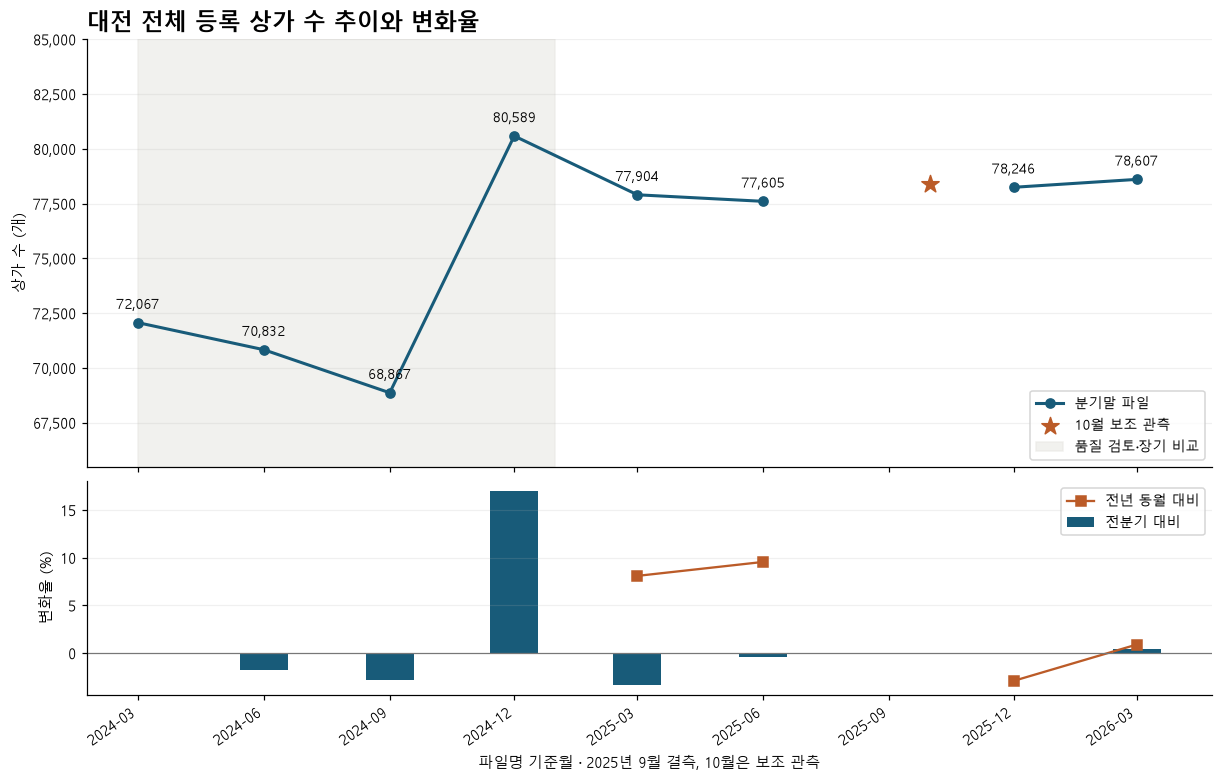

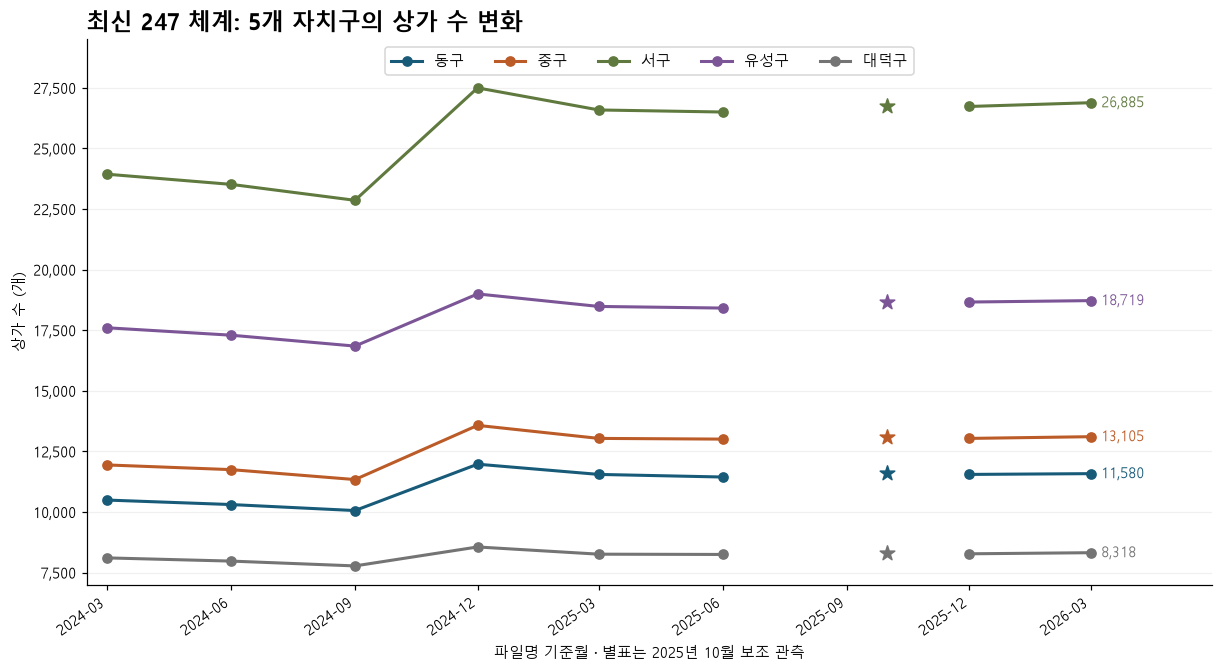

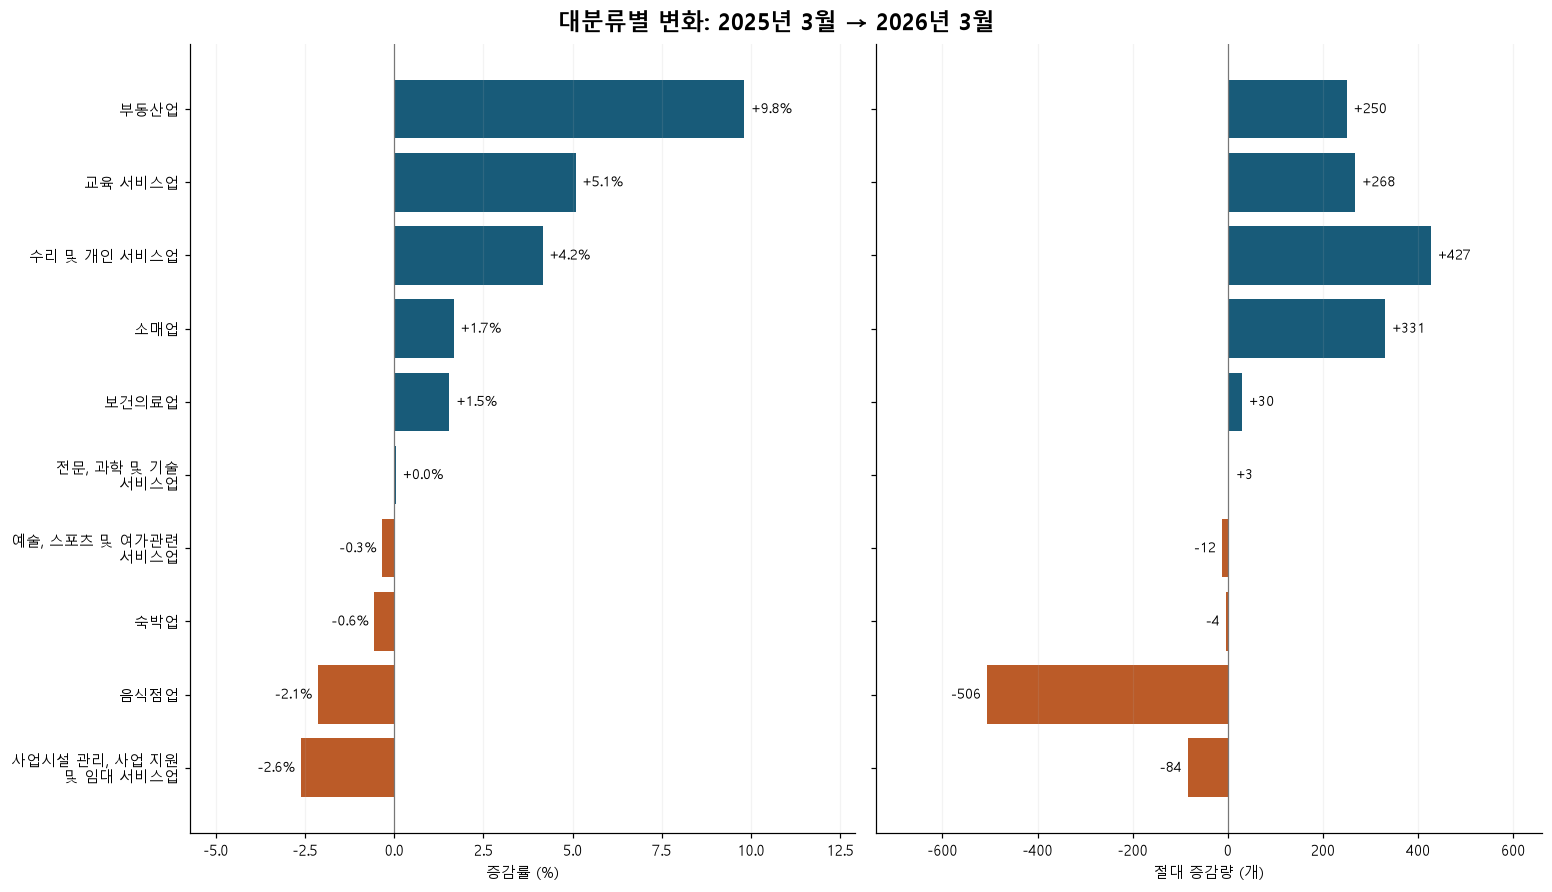

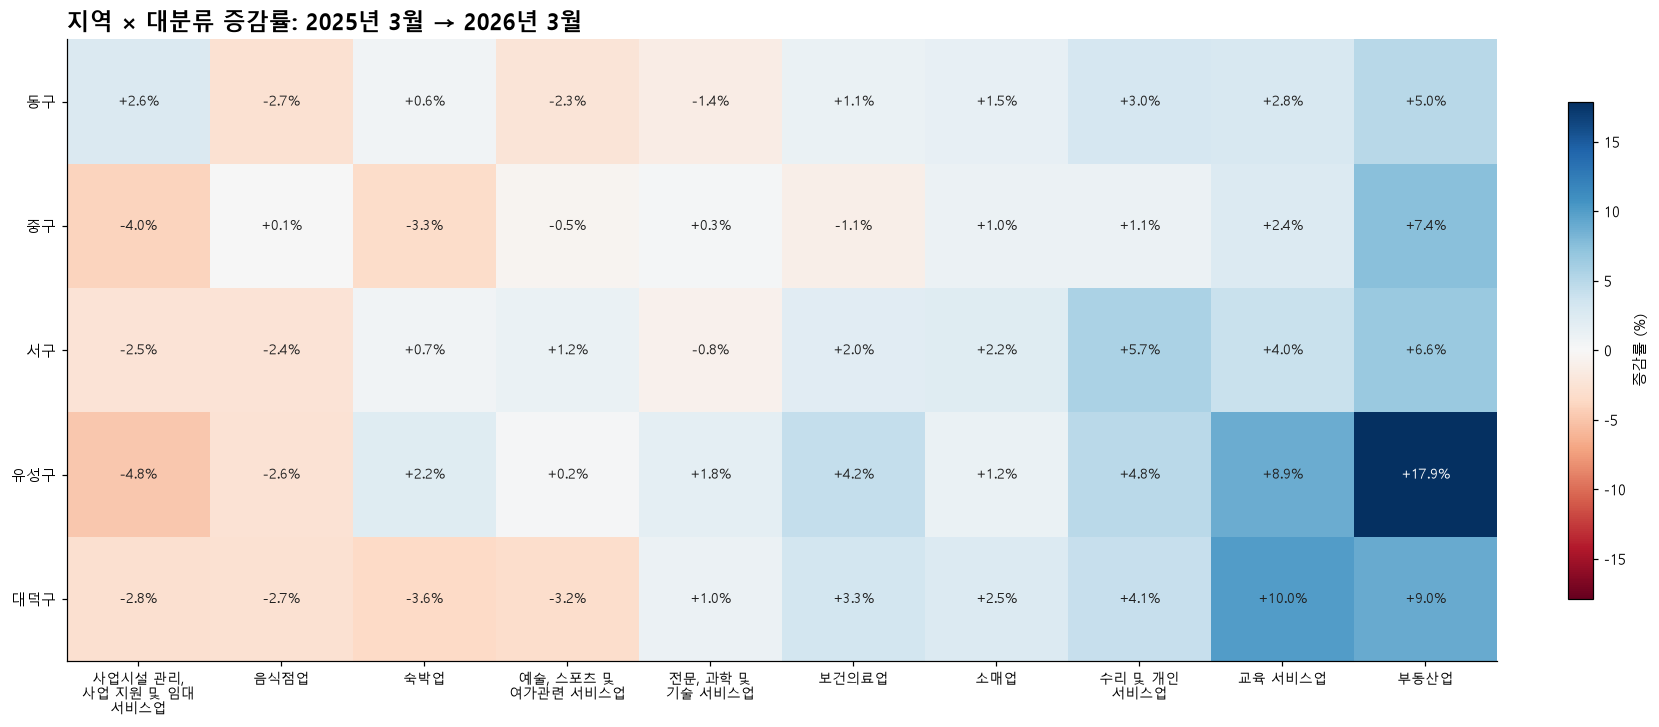

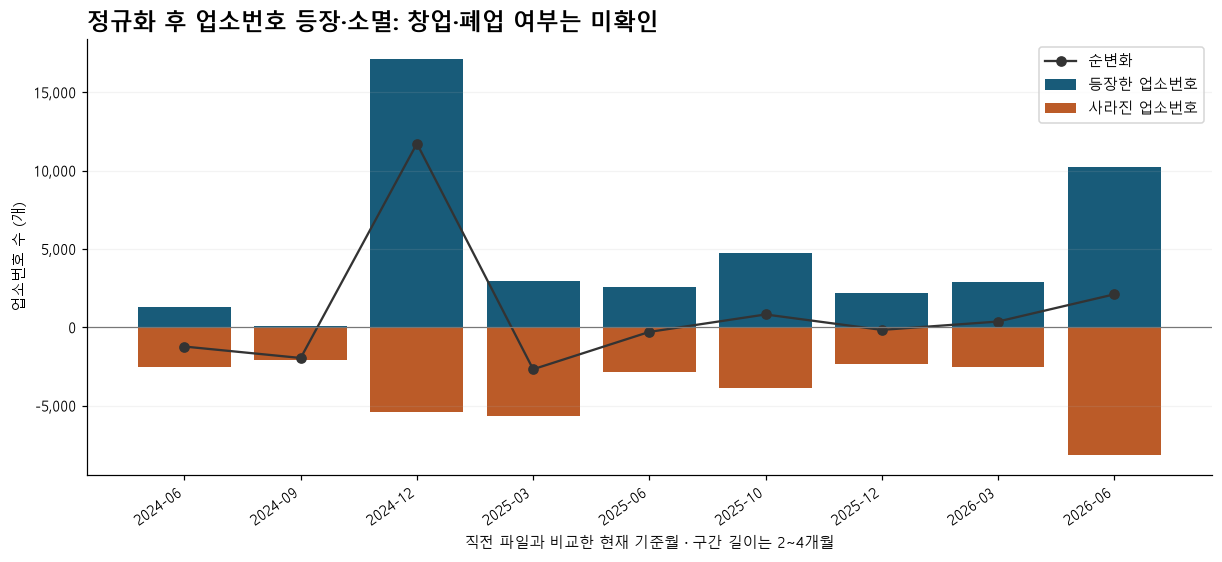

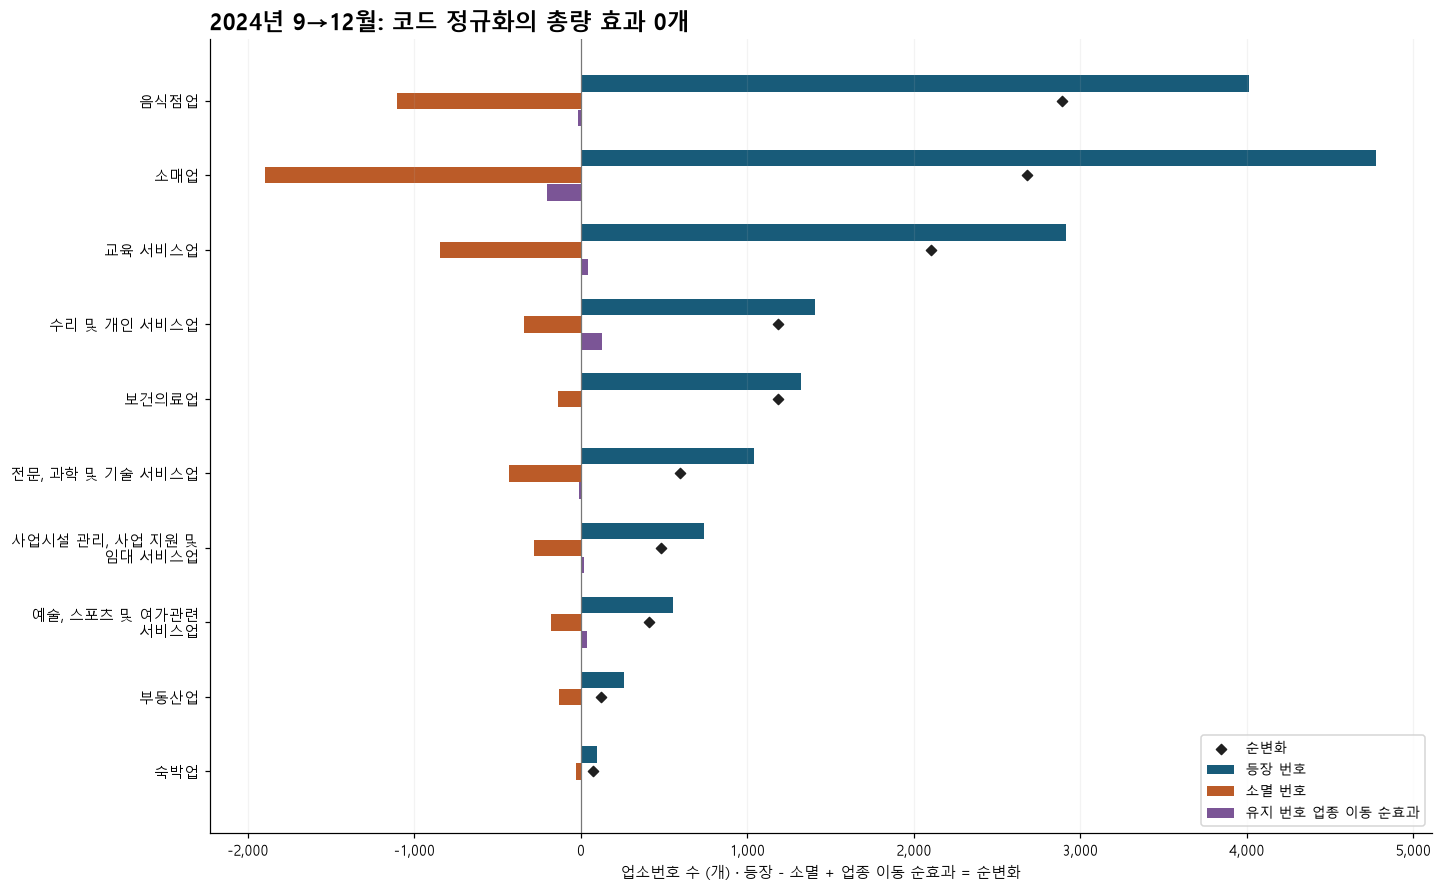

In [11]:
def save_figure(fig, filename):
    fig.savefig(IMAGES / filename, dpi=170, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)

def time_axis(ax):
    ax.set_xticks(quarter_index)
    ax.set_xticklabels([p.strftime('%Y-%m') for p in quarter_index], rotation=35, ha='right')
    ax.grid(axis='y', alpha=.18)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

fig, (ax, rates_ax) = plt.subplots(2, 1, figsize=(11, 7), gridspec_kw={'height_ratios': [2, 1]}, sharex=True, layout='constrained')
ax.plot(total.index, total.store_count, marker='o', color='#185b79', linewidth=2, label='분기말 파일')
extra = observed.loc[~observed.index.month.isin(quarter_months)]
ax.scatter(extra.index, extra.store_count, marker='*', s=140, color='#bb5b28', label='10월 보조 관측', zorder=5)
ax.axvspan(periods[0], pd.Timestamp('2024-12-31'), color='#e9e8e4', alpha=.6, label='품질 검토·장기 비교')
for p, value in total.store_count.dropna().items():
    ax.annotate(f'{value:,.0f}', (p, value), xytext=(0, 9), textcoords='offset points', ha='center', fontsize=9)
ax.set_ylim(65500, 85000)
ax.set_title('대전 전체 등록 상가 수 추이와 변화율', loc='left', fontweight='bold', fontsize=15)
ax.set_ylabel('상가 수 (개)')
ax.legend(loc='lower right', fontsize=9)
rates_ax.bar(total.index, total.qoq_pct, width=35, color='#185b79', label='전분기 대비')
rates_ax.plot(total.index, total.yoy_pct, marker='s', color='#bb5b28', label='전년 동월 대비')
rates_ax.axhline(0, color='#777777', linewidth=.8)
rates_ax.set_ylabel('변화율 (%)')
rates_ax.set_xlabel('파일명 기준월 · 2025년 9월 결측, 10월은 보조 관측')
rates_ax.legend(fontsize=9)
time_axis(ax)
time_axis(rates_ax)
save_figure(fig, '01_total_store_trend.png')

fig, ax = plt.subplots(figsize=(11, 6), layout='constrained')
palette = ['#185b79', '#bb5b28', '#5f793e', '#7b5596', '#747474']
for name, color in zip(district_order, palette):
    series = district[name].reindex(quarter_index)
    ax.plot(series.index, series, marker='o', label=name, color=color, linewidth=2)
    ax.scatter(extra.index, district.loc[extra.index, name], marker='*', color=color, s=100)
    ax.annotate(f'{district.loc[END, name]:,}', (END, district.loc[END, name]), xytext=(7, 0), textcoords='offset points', color=color, va='center')
ax.set_xlim(periods[0] - pd.Timedelta(days=15), END + pd.Timedelta(days=90))
ax.set_ylim(7000, 29500)
ax.set_title('최신 247 체계: 5개 자치구의 상가 수 변화', loc='left', fontweight='bold', fontsize=15)
ax.set_ylabel('상가 수 (개)')
ax.set_xlabel('파일명 기준월 · 별표는 2025년 10월 보조 관측')
ax.legend(ncol=5, loc='upper center', bbox_to_anchor=(.5, 1.0))
time_axis(ax)
save_figure(fig, '02_district_trend.png')

plot_growth = category_growth.sort_values('growth_pct')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True, layout='constrained')
colors = ['#185b79' if x >= 0 else '#bb5b28' for x in plot_growth.growth_pct]
category_labels = [textwrap.fill(name, 15) for name in plot_growth.index]
ax1.barh(category_labels, plot_growth.growth_pct, color=colors)
ax2.barh(category_labels, plot_growth.change, color=colors)
for axis, values, fmt in [(ax1, plot_growth.growth_pct, '{:+.1f}%'), (ax2, plot_growth.change, '{:+,d}')]:
    axis.axvline(0, color='#777777', linewidth=.8)
    axis.grid(axis='x', alpha=.15)
    axis.margins(x=.25)
    for y, value in enumerate(values):
        axis.annotate(fmt.format(value), (value, y), xytext=(4 if value >= 0 else -4, 0), textcoords='offset points', va='center', ha='left' if value >= 0 else 'right', fontsize=9)
ax1.set_xlabel('증감률 (%)')
ax2.set_xlabel('절대 증감량 (개)')
fig.suptitle('대분류별 변화: 2025년 3월 → 2026년 3월', fontsize=15, fontweight='bold')
save_figure(fig, '03_category_growth.png')

heat = combination_growth.growth_pct.unstack('category').reindex(index=district_order, columns=plot_growth.index)
bound = max(1, np.nanmax(np.abs(heat.to_numpy())))
fig, ax = plt.subplots(figsize=(15, 6.5), layout='constrained')
mesh = ax.imshow(heat, cmap='RdBu', vmin=-bound, vmax=bound, aspect='auto')
ax.set_xticks(range(len(heat.columns)), [textwrap.fill(name, 10) for name in heat.columns], fontsize=9)
ax.set_yticks(range(len(heat.index)), heat.index)
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        value = heat.iloc[i, j]
        ax.text(j, i, f'{value:+.1f}%', ha='center', va='center', color='white' if abs(value) > bound * .58 else '#202020', fontsize=9)
fig.colorbar(mesh, ax=ax, label='증감률 (%)', shrink=.8)
ax.set_title('지역 × 대분류 증감률: 2025년 3월 → 2026년 3월', loc='left', fontweight='bold', fontsize=15)
save_figure(fig, '04_district_category_heatmap.png')

fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
x = np.arange(len(transitions))
ax.bar(x, transitions.appeared, label='등장한 업소번호', color='#185b79')
ax.bar(x, -transitions.disappeared, label='사라진 업소번호', color='#bb5b28')
ax.plot(x, transitions.net_change, marker='o', color='#333333', label='순변화')
ax.axhline(0, color='#777777', linewidth=.8)
ax.set_xticks(x, [p.strftime('%Y-%m') for p in transitions.period], rotation=35, ha='right')
ax.set_title('정규화 후 업소번호 등장·소멸: 창업·폐업 여부는 미확인', loc='left', fontweight='bold', fontsize=15)
ax.set_xlabel('직전 파일과 비교한 현재 기준월 · 구간 길이는 2~4개월')
ax.set_ylabel('업소번호 수 (개)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.legend()
ax.grid(axis='y', alpha=.15)
save_figure(fig, '05_id_turnover.png')
fig, ax = plt.subplots(figsize=(13, 8), layout='constrained')
decomp_plot = shock_decomposition.sort_values('change')
y = np.arange(len(decomp_plot))
ax.barh(y + .23, decomp_plot.appeared, height=.22, color='#185b79', label='등장 번호')
ax.barh(y, -decomp_plot.disappeared, height=.22, color='#bb5b28', label='소멸 번호')
ax.barh(y - .23, decomp_plot.reclassification_net, height=.22, color='#7b5596', label='유지 번호 업종 이동 순효과')
ax.scatter(decomp_plot.change, y, marker='D', color='#202020', s=22, label='순변화', zorder=4)
ax.set_yticks(y, [textwrap.fill(name, 16) for name in decomp_plot.category])
ax.axvline(0, color='#777777', linewidth=.8)
ax.set_xlabel('업소번호 수 (개) · 등장 - 소멸 + 업종 이동 순효과 = 순변화')
ax.set_title('2024년 9→12월: 코드 정규화의 총량 효과 0개', loc='left', fontweight='bold', fontsize=15)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.grid(axis='x', alpha=.15)
ax.legend(loc='lower right', fontsize=9)
save_figure(fig, '06_classification_scope_decomposition.png')


## 9. 실제 집계값으로 리포트 생성
아래 수치는 앞선 결과 변수에서 삽입합니다. 외부 원인에 대한 문장은 가설로 표시하며, 확인되지 않은 인과관계는 쓰지 않습니다.

In [12]:
def markdown_table(table):
    """별도 표 변환 패키지 없이 작은 마크다운 표를 출력합니다."""
    table = table.copy()
    def cell(value):
        if pd.isna(value):
            return '—'
        if isinstance(value, (pd.Timestamp, np.datetime64)):
            return pd.Timestamp(value).strftime('%Y-%m')
        if isinstance(value, (float, np.floating)):
            return f'{value:,.2f}'
        if isinstance(value, (int, np.integer)):
            return f'{value:,}'
        return str(value).replace('|', '\\|')
    return '\n'.join(['| ' + ' | '.join(map(str, table.columns)) + ' |',
                      '| ' + ' | '.join(['---'] * len(table.columns)) + ' |'] +
                     ['| ' + ' | '.join(cell(v) for v in row) + ' |' for row in table.itertuples(index=False, name=None)])

def growth_display(table, index_name):
    return table.reset_index().iloc[:, :5].set_axis([index_name, '시작 상가 수', '종료 상가 수', '증감(개)', '증감률(%)'], axis=1)

start_count, end_count = int(observed.loc[MAIN_START, 'store_count']), int(observed.loc[END, 'store_count'])
net = end_count - start_count
main_growth = net / start_count * 100
long_growth = (end_count / observed.store_count.iloc[0] - 1) * 100
shock = transitions.loc[transitions.period.eq('2024-12-01')].iloc[0]
last_transition = transitions.iloc[-1]
pre_end = pd.Timestamp('2026-03-01')
pre_net = int(observed.loc[pre_end, 'store_count']) - start_count
pre_growth = pre_net / start_count * 100
district_rate_leader = district_growth.growth_pct.idxmax()
district_absolute_leader = district_growth.change.idxmax()
best_category = category_growth.change.idxmax()
worst_category = category_growth.change.idxmin()
category_rate_leader = category_growth.growth_pct.idxmax()
latest_category_change = category.loc[END] - category.loc[pre_end]
latest_decline_category = latest_category_change.idxmin()
best_combo = combination_growth.growth_pct.idxmax()
worst_combo = combination_growth.growth_pct.idxmin()
opposite = combination_growth.loc[combination_growth.opposite_direction].sort_values('difference_pp', key=abs, ascending=False)
big_middle = middle_growth.change.idxmax()
health_shock = (category.loc['2024-12-01', major_names['Q1']] / category.loc['2024-09-01', major_names['Q1']] - 1) * 100
education_shock = (category.loc['2024-12-01', major_names['P1']] / category.loc['2024-09-01', major_names['P1']] - 1) * 100
file_display = audit[['period', 'file', 'raw_rows', 'columns', 'duplicate_ids']].set_axis(['기준월', '파일명', '행 수', '컬럼 수', '중복 업소번호'], axis=1)
total_display = total.reset_index().set_axis(['기준월', '상가 수', '전분기 대비(%)', '전년 동월 대비(%)'], axis=1)
total_display['상가 수'] = total_display['상가 수'].astype('Int64')
transition_display = transitions[['previous_period', 'period', 'common', 'appeared', 'disappeared', 'net_change', 'common_category_changed', 'common_district_changed', 'same_name_address_keys']].set_axis(['이전', '현재', '유지', '등장', '소멸', '순변화', '유지번호 업종변경', '유지번호 구변경', '상호·주소 일치 키'], axis=1)
missing_display = missing.groupby('column', as_index=False).agg(total_missing=('missing_count', 'sum'), max_missing_pct=('missing_pct', 'max'))
missing_display = missing_display.loc[missing_display.total_missing.gt(0)].sort_values('total_missing', ascending=False).set_axis(['컬럼', '전체 결측 수', '파일별 최대 결측률(%)'], axis=1)
classification_display = codes.groupby(['period', 'level']).size().unstack().reindex(columns=['대', '중', '소']).reset_index().set_axis(['기준월', '대분류', '중분류', '소분류'], axis=1)
main_rows = int(panel.is_main.sum())
quarter_rows = int(panel.is_quarter_end_snapshot.sum())
source_url = 'https://www.data.go.kr/data/15083033/fileData.do'
split_reference = legacy.loc[legacy.mapping_type.eq('분리')]
usage_display = pd.DataFrame({'매핑 유형': ['유지', '통합', '분리', '제외', '추가', '미매핑']})
usage_counts = normalized.groupby('mapping_type').agg(관측행=(ID, 'size'), 고유업소번호=(ID, 'nunique'), 원본소분류=('source_small_code', 'nunique'))
usage_display = usage_display.join(usage_counts, on='매핑 유형').fillna(0)
for col in ['관측행', '고유업소번호', '원본소분류']:
    usage_display[col] = usage_display[col].astype(int)
name_change_display = name_changes.groupby('level')[['name_changed_rows', 'code_changed_rows']].sum().reset_index()
name_change_display['level'] = name_change_display.level.map({'major': '대분류', 'middle': '중분류', 'small': '소분류'})
name_change_display.columns = ['수준', '명칭 변경 관측행', '코드 변경 관측행']
added_only_counts = normalized.loc[normalized.source_small_code.isin(added_only_codes)].groupby('period').size()
added_range_counts = normalized.loc[normalized.source_small_code.isin(added_codes)].groupby('period').size()
shock_mapping_effect = float(total_comparison.loc['2024-12-01', 'difference'] - total_comparison.loc['2024-09-01', 'difference'])
changed_common_count = int(shock_decomposition.common_reclassified_in.sum())
reference_type_display = crosswalk_summary.set_axis(['연계표 비고', '원본 행', '구 코드 수', '신 코드 수', '중복 제거 행'], axis=1)
total_compare_display = total_comparison.reset_index().set_axis(['기준월', '정규화 전', '정규화 후', '차이(개)'], axis=1)
decomp_display = shock_decomposition[['category', 'before_count', 'after_count', 'change', 'appeared', 'disappeared', 'reclassification_net']].set_axis(
    ['최신 대분류', '2024-09', '2024-12', '순변화', '등장', '소멸', '유지번호 업종이동 순효과'], axis=1)
normalization_section = f'''
## 4.4 최신 247개 업종체계 정규화

### 정규화 이유와 기준

시점마다 다른 업종명·코드 체계를 그대로 비교하면 통합·분리·명칭 변경이 실제 상가 수 변화처럼 보일 수 있다. 이를 방지하기 위해 사용자가 제공한 **`{crosswalk_path.name}`**의 **`1. 상권_업종분류(247)` A3:F249**를 목표 분류로, **`3. 상권_업종연계표(837-247)` A3:I893**을 구→신 관계로 사용했다. “최신”은 이 분석에서 **첨부표의 247개 목표 체계**를 뜻한다. 첨부표에 적용 기준일이 명시되어 있지 않으므로 체계 도입 시기를 2024년 말이라고 추정하지 않는다.

원본의 모든 소분류 코드를 양쪽 코드 집합과 대조한 결과, **{len(normalized):,}개 관측행·{normalized[ID].nunique():,}개 고유 업소번호·{normalized.source_small_code.nunique()}개 소분류가 이미 247개 체계에 속했다.** 구 837 코드 적용 행은 **{int(mapping_audit.legacy_rows.sum()):,}개**, 미확인 코드 행은 **{int(normalized.mapping_type.eq('미매핑').sum()):,}개**다. 신·구 코드 집합은 겹치지 않는다. 따라서 과거 파일을 구 837 체계라고 가정하지 않고 최신 코드는 유지하며 첨부표의 정식 명칭으로 통일했다.

**정규화 대상은 2024~2026년 전체 10개 파일이다.** 기존 결과와 비교하기 위해 메인 성장률 구간은 2025-03~2026-06을 유지하고, 2024-03~2026-06 전체 비교도 아래와 6.3절에 제시한다. 2024년 말의 수록 건수 단절은 정규화 이후에도 남으므로 전체 구간의 증가율을 순수한 상권 성장률로 해석하지 않는다.

### 연계표 유형과 안전한 매핑

{markdown_table(reference_type_display)}

연계표는 데이터 행 **{len(original_edges):,}개**이며 완전히 같은 행 **{len(original_edges)-len(edges)}개**를 관계 계산에서만 제거해 **{len(edges):,}개**를 사용했다. 원본 엑셀은 수정하지 않았다. 같은 구 코드가 여러 유형에 나타날 수 있어 유형별 고유 구 코드 수는 합산할 수 없다.

- **유지:** 구→신 후보가 하나거나, 원본 코드가 이미 목표 247 체계인 경우. 후자는 `mapping_basis=최신코드 직접확인`으로 구분한다.
- **통합:** 여러 구 분류가 하나의 신 분류로 연결된다. 업종을 합치지만 업소 행을 합치거나 중복 생성하지 않는다. 원본 업소번호 기준 한 행을 유지한다.
- **분리:** 비고 문구보다 실제 구 코드의 후보 집합을 우선한다. 후보가 여러 개면 소분류를 임의 선택·균등 배분하지 않는다. 모든 후보가 같은 중분류면 중분류·대분류만 확정하고, 중분류는 달라도 대분류가 같으면 대분류만 확정한다. 대분류까지 갈리면 해당 후보의 상위 집계도 완전한 값으로 발표하지 않는다.
- **제외:** 목표 체계에 대응 코드가 없는 구 분류다. 행을 삭제해 흔적을 없애지 않고 정규화 기록에 남기며 분류별 분석에서 제외한다.
- **추가:** 구 대응이 없는 새 대상 범위다. 과거 구 체계 자료의 값을 0으로 채우지 않는다. `store_count`를 결측으로, 확인된 일부 수는 `confirmed_count`에 남긴다. 이미 최신 체계에서 직접 관측된 업소는 실제 관측값을 사용한다.

`mapping_type`은 **이번에 실제 수행한 코드 변환 유형**, `mapping_confidence`는 **소분류확정 / 중분류확정 / 대분류확정 / 제외확정 / 미확정**을 뜻한다. 확률 점수가 아니다. 표의 과거 비고는 `crosswalk_types`에 별도로 기록했다. 예컨대 구 체계에서 추가됐던 병원 업종도 2024년 원본에 최신 코드로 직접 존재하면 이번 업소 변환은 **유지·소분류확정**, `is_added_category=True`다. 추가 유형은 별도 대상 업종 이력표에도 보존했다.

1:N 관계는 실제로 **{len(split_reference)}개 구 코드**다. 비고가 분리인 고유 구 코드 **{int(crosswalk_summary.set_index('crosswalk_type').loc['분리', 'old_codes'])}개**만 찾으면 일부 분리를 놓친다.

{markdown_table(split_reference[['source_small_code', 'candidate_small_codes', 'crosswalk_types', 'mapping_confidence']].set_axis(['구 소분류 코드', '신 소분류 후보', '원본 비고', '확정 수준'], axis=1))}

실제 관계 기준으로 **{int(split_reference.mapping_level.eq('middle').sum())}개**는 중분류까지만 확정 가능하고, **{int(split_reference.mapping_level.eq('none').sum())}개**는 대분류도 불확정이다. 이 관계는 구현·검증했지만 해당 구 코드를 쓰는 실제 관측행은 **0개**였다. 테스트 사례의 상위 매핑을 실데이터에서 발생한 것처럼 보고하지 않았다.

### 실제 적용 건수·명칭 변경·추가 업종

{markdown_table(usage_display)}

표의 관측행은 시점별 반복 수록을 포함하며 고유 업소번호와 다르다. **분류 분석 제외 {int(mapping_audit.excluded_rows.sum()):,}행·{normalized.loc[normalized.mapping_type.eq('제외'), 'source_small_code'].nunique()}개 원본 업종**, **상위 수준에서만 매핑 {int(mapping_audit.middle_only.sum()+mapping_audit.major_only.sum()):,}행·{normalized.loc[normalized.mapping_level.isin(['middle', 'major']), 'source_small_code'].nunique()}개 원본 업종**, **미확정 {int(mapping_audit.unresolved_rows.sum()):,}행**이다.

{markdown_table(mapping_audit[['period', 'raw_rows', 'latest_rows', 'legacy_rows', 'small_confirmed', 'middle_only', 'major_only', 'excluded_rows', 'unresolved_rows']].set_axis(['기준월', '관측행', '기존부터247', '구837', '소분류확정', '중분류만', '대분류만', '제외', '미확정'], axis=1))}

{markdown_table(name_change_display)}

명칭 변경에는 `소매→소매업`, `과학·기술→전문, 과학 및 기술 서비스업` 같은 정식 명칭 통일과 소분류의 세미콜론·쉼표 차이가 포함된다. 명칭 변경 행 수를 업종 이동이나 신규 업소 수로 해석하지 않는다.

추가 비고는 **{int(crosswalk_summary.set_index('crosswalk_type').loc['추가', 'original_rows'])}행**, 고유 목표 코드는 **{len(added_codes)}개**다. 그중 **{len(added_only_codes)}개**는 구 대응이 전혀 없고, 나머지 **{len(added_codes)-len(added_only_codes)}개(`M11201`, 인테리어 디자인업)**는 추가와 통합 관계가 함께 있어 과거 구 체계 집계만으로 신규 범위 전체를 복원할 수 없다. 추가 비고의 중복 행을 신규 업종 수로 세지 않았다.

이 {len(added_codes)}개 목표 업종은 이미 **모든 원본 시점에서 실제 관측**된다. 구 대응이 전혀 없는 {len(added_only_codes)}개 업종의 수록 업소는 2024-03 **{int(added_only_counts.loc['2024-03-01']):,}개**, 2024-09 **{int(added_only_counts.loc['2024-09-01']):,}개**, 2024-12 **{int(added_only_counts.loc['2024-12-01']):,}개**다. 따라서 과거 값은 0이 아니라 이 관측값이다. 전체 신규 범위의 역사적 창업 시점을 뜻하지 않는다. [추가 업종 이력표](data/processed/added_category_history.csv)에 40개×10개 관측을 보존했다.

첨부표 247개 중 `I20601 / 분류 안된 외국식 음식점`은 전 시점 대전 원본에서 미관측이다. 이 코드는 추가 유형이 아니며, 최신 체계로 수록된 대전 파일 내 미관측 건수는 0으로 기록했다. 이는 구 체계에 대응이 없어 관측할 수 없는 값과 다르며 실제 지역에 업소가 절대 없다는 보증도 아니다.

### 재분류 전후 결과 비교

{markdown_table(total_compare_display)}

기존 저장 패널과 비교한 **{len(new_panel_comparison)}개 구×업종×시점**에서 상가 수 차이는 모두 **0개**, **100개 대분류×시점**에서도 차이는 **0개**다. 전분기·전년 동기 변화율의 최대 절대 차이는 각각 **{new_panel_comparison.qoq_difference_pp.abs().max():.8f}%p**, **{new_panel_comparison.yoy_difference_pp.abs().max():.8f}%p**이고 결측 위치도 동일하다. 전체 구간 증가율 **{long_growth:+.2f}%**, 기존 메인 구간 증가율 **{main_growth:+.2f}%**는 바뀌지 않았다. 그림·표·인사이트는 유지된 수치와 최신 명칭으로 다시 생성했다.

### 2024년 말 급증: 설명 가능한 부분과 식별할 수 없는 부분

![2024년 말 업종별 변화 분해](images/06_classification_scope_decomposition.png)

{markdown_table(decomp_display)}

분해식은 **업종별 순변화 = 등장 번호 수 − 소멸 번호 수 + 유지 번호의 해당 업종 유입 − 유출**이다. 모든 업종·모든 연속 관측에서 이 등식을 검증했다.

1. **837→247 정규화로 제거되는 총량 증가분은 {shock_mapping_effect:,.0f}개({shock_mapping_effect / shock.net_change * 100:.2f}%)다.** 2024년 9월과 12월 모두 이미 목표 코드를 사용하므로 코드 체계 변환을 다시 적용해도 순증 **{int(shock.net_change):+,}개({shock.observed_change_pct:+.2f}%)**가 그대로다. 코드 체계 불일치를 이 급증의 원인으로 볼 근거는 확인되지 않았다.
2. 유지 업소번호 중 최신 대분류가 바뀐 업소는 **{changed_common_count:,}개**다. 업종별 구성은 변하지만 대분류 전체에서 유입·유출이 상쇄되어 **총 상가 수 기여는 {int(shock_decomposition.reclassification_net.sum()):,}개**다. 이것은 동일 체계 안의 관측 분류 변경이며 체계 도입 효과로 확정하지 않는다.
3. 전체 순증 **{int(shock.net_change):,}개**는 **등장 {int(shock.appeared):,}개 − 소멸 {int(shock.disappeared):,}개**와 일치한다. 산술적으로 식별자 집합 변화가 순증 전부를 설명하지만, **이를 수집범위 확대 100%라고 해석할 수는 없다.** 실제 개폐업, 수집범위 확대·정비, 등록 지연, 식별자 재발급의 기여 비중은 이 자료만으로 추정할 수 없다.
4. 새로 등장한 번호와 소멸한 번호 사이의 동일 상호·도로명주소 조합이 **{int(shock.same_name_address_keys):,}개**여서 식별자 교체 가능성이 있다. 그러나 동일 업소 확정 매칭이 아니므로 이를 창업·폐업 건수에서 임의 차감하지 않았다.

**판단:** 정규화에 따른 집계 변화는 0으로 측정할 수 있다. 수집범위 변화의 가능성은 남지만 그 효과를 실제 사업체 변화와 분리한 비율은 식별 불가다. 제공기관의 시점별 수집·정비 이력과 개폐업 자료가 필요하다.

매핑 함수·안전성 검증은 `classification.py`, `test_mapping.py`에 있으며, 모든 업소별 결과는 [정규화 관측 기록](data/processed/normalized_store_records.csv.gz), 구 체계 전체의 매핑은 [코드별 매핑표](data/processed/code_mapping.csv), 업종 이동은 [유지 업소 분류 이동표](data/processed/common_reclassification_flows.csv)에 저장했다.
'''

report = f'''# 대전광역시 상권 변화 시계열 분석

## 1. 분석 배경 및 목적

첨부표의 최신 247개 업종 체계로 2024~2026년 전체 원본을 정규화한 뒤 대전광역시의 지역·업종별 상가 수가 어떻게 변했는지 비교하고, 관측된 변화가 실제 상권 성장인지 데이터 수집·정비 영향인지 구분하기 위한 분석이다. 분석 대상은 공공데이터 파일에 수록된 업소 수이며 법적 사업자등록 통계나 매출 통계가 아니다. 이하 “등록 상가 수”는 이 파일 수록 건수를 뜻한다.

메인 비교 구간은 **2025년 3월~2026년 6월**이다. 전체 상가 수는 **{start_count:,}개 → {end_count:,}개, {net:+,}개({main_growth:+.2f}%)**다. 다만 증가분 중 **{last_transition.net_change / net * 100:.2f}%**가 업소번호 교체가 큰 마지막 구간에 집중되어 있다. 정규화 전후 전체 수와 대분류별 집계는 동일하다. 숫자의 증가를 창업 증가나 매출 개선으로 단정하지 않는 것이 이 분석의 핵심이다.

## 2. 분석 질문

1. 전체 등록 상가 수는 어떤 추세이며, 전분기·전년 동기 변화는 어떠한가?
2. 대전 5개 자치구의 변화 방향과 규모는 어떻게 다른가?
3. 어떤 대분류 업종이 전체 증가·감소에 크게 기여했는가?
4. 어느 구×업종 조합이 빠르게 변했고, 대전의 같은 업종과 반대 방향으로 움직였는가?

## 3. 데이터 설명

- 출처: 소상공인시장진흥공단, [공공데이터포털 상가(상권)정보]({source_url}). 공공데이터포털에서 수집하여 사용자가 제공한 대전 지역 CSV를 사용했다. 이번 분석에서 원본을 새로 다운로드하거나 파일명을 변경하지 않았다.
- 기준월: 2024-03~2026-06, 파일 **{len(files)}개**, 원본 **{audit.raw_rows.sum():,}행**. 같은 업소가 여러 시점에 반복되므로 이 합계는 고유 업소 수가 아니다.
- 각 파일은 **{len(base_columns)}개 컬럼**. 핵심은 상가업소번호, 시군구코드·명, 상권업종 대·중·소분류 코드·명이다.
- `period`는 파일명에서 추출한 기준월의 1일이다. 실제 조사일·개업일을 뜻하지 않는다. 별도의 관측일 컬럼은 없다.
- 분석 단위: 구×대분류×관측월 **{len(panel):,}개 패널 관측치**, 그중 분기말 자료 **{quarter_rows:,}개**, 메인 구간 분기말 자료 **{main_rows:,}개**. 5개 구×10개 업종의 반복 관측이다.
- **시간축은 10개 관측월, 정상 분기말은 9개뿐이다.** 메인 구간도 분기말 5개와 10월 보조 관측 1개다. 패널의 500행을 500개 시간 시점으로 해석하면 안 된다. 미션의 “100개 데이터 포인트”를 패널 관측치 기준으로 충족하며, 평가 기준이 단일 시계열의 100개 시점이라면 이 자료만으로는 미충족이다.
- 2025-09 파일이 없고 2025-10 파일이 있다. 10월을 3분기라고 간주하지 않는다. 10월과 12월은 같은 달력상 4분기지만 중복 합산하지 않으며 분기말 대표값은 12월이다.

{markdown_table(file_display)}

## 4. 데이터 정제 및 품질 확인

### 4.1 컬럼·결측·중복

모든 파일의 컬럼명과 순서가 동일하다. 코드를 문자열로 읽어 선행 0을 보존하고, 빈 문자열·공백을 결측으로 통일했다. 상가업소번호·시도·구·상권업종 코드 및 명칭의 결측은 **{audit.core_missing.sum():,}건**, 파일 내 중복 업소번호는 **{audit.duplicate_ids.sum():,}건**, 완전 중복 행은 **{audit.exact_duplicates.sum():,}건**이다. 따라서 집계용 행 삭제·추정값 대체는 하지 않았다. 같은 번호가 다른 시점에 반복되는 것은 정상적인 반복 관측이므로 제거하지 않는다.

지점명·건물명·층·동·호 등은 결측이 많지만 분석 집계에 쓰지 않으므로 그대로 보존했다. 표준산업분류의 일부 결측도 상권업종 분류가 존재하므로 제외 사유가 아니다. 좌표의 숫자 변환·전 세계 유효 범위 검사에서 **{audit.invalid_coordinates.sum():,}건**이 발견됐다. 좌표를 집계에 사용하지 않으며, 이 검사는 대전 경계 내부 여부를 보증하지 않는다.

{markdown_table(missing_display)}

컬럼별·파일별 전체 결측표는 [missing_values.csv](data/processed/missing_values.csv), 컬럼명 39개와 순서는 [schema.csv](data/processed/schema.csv)에 저장했다. 핵심 컬럼 결측이나 내용이 충돌하는 식별자 중복을 새로 발견하면 코드가 중단되어 임의 집계하지 않는다.

### 4.2 행정구역과 업종 분류

전 기간 시도는 `30 / 대전광역시`이며, 구 코드·명은 `30110 / 동구`, `30140 / 중구`, `30170 / 서구`, `30200 / 유성구`, `30230 / 대덕구`로 동일하다. 행정동·법정동을 포함한 시점별 코드표와 변경 수는 [administrative_codes.csv](data/processed/administrative_codes.csv), [administrative_changes.csv](data/processed/administrative_changes.csv)에 남겼다. 구 단위 비교와 달리 동 경계의 공간적 동일성은 보증하지 않는다.

행정동·법정동 코드·명칭 집합에서도 관측 시점 간 추가·삭제는 없었다. 로컬 파일의 상권업종은 전 기간 **대분류 10개·중분류 74개·소분류 246개**이고 코드·명칭 집합의 추가·삭제가 없다. [공식 데이터 설명]({source_url})의 전국 체계는 10·75·247개로, 대전에서 관측된 집합과 구분한다. 전국 분류 중 대전 자료에 없는 업종이 있을 수 있으며, 이를 곧바로 누락 오류로 판단하지 않는다. 분류 집합은 동일해도 개별 업소의 분류 수정이나 수집 범위 변경은 가능하다.

{markdown_table(classification_display)}

### 4.3 업소번호 전이와 이상 징후

{markdown_table(transition_display)}

“유지”는 두 파일에 모두 존재하는 번호다. “등장”과 “소멸”은 각각 집합 차집합으로 계산했다. 모든 구간에서 `등장−소멸=상가 수 순변화`를 검증했다. 마지막 열은 사라진 번호와 새 번호 사이에서 **상호명·도로명주소가 모두 같은 고유 조합 수**이며, 동일 실제 업소임을 확정하는 매칭은 아니다.

- 가장 큰 순증은 2024-09→2024-12의 **{int(shock.net_change):+,}개({shock.observed_change_pct:+.2f}%)**다. **{int(shock.appeared):,}개 등장·{int(shock.disappeared):,}개 소멸**이 동반됐다. 같은 구간 보건의료는 **{health_shock:+.2f}%**, 교육은 **{education_shock:+.2f}%**다. 2024→2025 경계보다 2024년 말의 단절이 더 크다.
- 2026-03→2026-06에는 **{int(last_transition.appeared):,}개 등장·{int(last_transition.disappeared):,}개 소멸**, 합계가 이전 업소 수의 **{last_transition.turnover_pct:.2f}%**다. 순증률 **{last_transition.observed_change_pct:+.2f}%**만 보면 이 교체 규모가 가려진다. 유지 번호의 대분류 변경도 **{int(last_transition.common_category_changed):,}건**이다.
- 이 급변을 오류라고 단정하여 삭제하거나 평활하지 않았다. 품질 경고로 보존하고, 메인 구간을 2025년 3월부터로 정하되 2026년 3월까지만 비교한 민감도 결과도 제시한다.
- 공식 페이지는 분기 갱신과 현재 분류체계를 설명하지만, **위 두 시점의 수집 범위 변경을 확정할 공지는 이번 확인에서 확보하지 못했다.** 수집·정비 영향은 가설이다. 실제 개폐업·자료 정비·등록 지연을 이 파일만으로 분리할 수 없다.

{normalization_section}

## 5. 분석 방법

1. **분기말 집계**: 파일명 월이 3·6·9·12월인 자료를 사용한다. 분기마다 구·업종별 업소번호 수를 집계한다. 원자료 주기와 맞추고 10월·12월 이중 합산을 방지하기 위함이다.
2. **전분기 변화율**: `(현재/3개월 전−1)×100`. 단순히 이전 행을 참조하지 않고 정확한 기준월을 찾는다. 2025년 9월이 없어 2025년 12월의 전분기 변화율은 계산하지 않는다.
3. **전년 동기 변화율**: `(현재/12개월 전−1)×100`. 같은 기준월을 비교하여 계절적 시점 차이를 줄인다. 그러나 2024년 말 단절을 가로지르는 비교는 수집 효과가 섞일 수 있어 별도 주의가 필요하다.
4. **기간 절대 증감·증감률**: 2025-03과 2026-06을 비교한다. 절대 증감량으로 총변화 기여를, 비율로 상대 변화를 본다. 분모가 0이면 비율은 결측으로 두고 절대량을 제시한다.
5. **구×업종 패널·선택적 중분류**: 50개 조합을 비교하고, 절대 증감량이 가장 큰 대분류 **{selected_category}**만 중분류로 살핀다.
6. **식별자 전이·민감도**: 같은 번호의 유지·등장·소멸과 2026년 6월 포함 여부를 비교하여 해석의 안정성을 점검한다.

추세는 여러 관측에 걸친 방향, 계절성은 같은 계절마다 반복되는 움직임, 노이즈는 일시적 변동을 뜻한다. 관측 분기가 짧고 결측·수집 단절이 있어 계절성을 확정할 수 없다. 이동평균·분해·예측은 핵심 문제를 해결하지 못하므로 적용하지 않았다. 전년 동기 변화율 자체가 계절성의 증명은 아니다.

## 6. 분석 결과

### 6.1 전체 상가 수와 변화율

![전체 상가 수와 전분기·전년 동기 변화율](images/01_total_store_trend.png)

{markdown_table(total_display)}

**관찰:** 2024-03→2026-06 전체 비교는 **{long_growth:+.2f}%**지만 2024년 말 단절을 포함한다. 메인 비교는 **{main_growth:+.2f}%**이고, 최근 분기 변화율은 **{total.loc[END, 'qoq_pct']:+.2f}%**, 전년 동기 대비는 **{total.loc[END, 'yoy_pct']:+.2f}%**다. 2025-10 보조 관측은 **{int(observed.loc['2025-10-01', 'store_count']):,}개**다. 선의 빈 부분은 자료 결측이며 0개를 뜻하지 않는다.

**해석:** 파일에 수록된 업소 수는 늘었지만, 성장의 속도와 지속성은 자료 갱신 영향을 함께 검토해야 한다. 상단 세로축은 0에서 시작하지 않으므로 상승의 시각적 크기보다 표의 변화율을 우선한다.

### 6.2 5개 자치구 비교

![대전 5개 구별 상가 수 변화](images/02_district_trend.png)

{markdown_table(growth_display(district_growth, '자치구'))}

**관찰:** 증가율 1위는 **{district_rate_leader}({district_growth.loc[district_rate_leader, 'growth_pct']:+.2f}%)**, 절대 증가량 1위는 **{district_absolute_leader}({int(district_growth.loc[district_absolute_leader, 'change']):+,}개)**다. 메인 구간 5개 구 중 **{int(district_growth.change.gt(0).sum())}개 구가 증가**, **{int(district_growth.change.lt(0).sum())}개 구가 감소**했다.

메인 시작 이후 정확한 전분기 비교가 가능한 구×시점 **{len(district_rate_comparison)}개** 중 대전 전체와 반대 방향인 경우는 **{int(district_rate_comparison.opposite_direction.sum())}개**였다. 구별 변화의 큰 방향은 같고 증가 폭이 다르다는 결론이다. 2025년 9월 결측 전후의 방향은 이 검증에 포함하지 않았다.

**해석:** 구별 총량과 상대 변화는 서로 다른 정보를 준다. 구별 성장 원인을 인구 이동·개발 등으로 확정하려면 추가 자료가 필요하다. 세로축은 0에서 시작하지 않으며 별표는 10월 보조 관측이다.

### 6.3 업종별 증감

**2024년 3월~2026년 6월 전체 구간: 최신 대분류별 비교**

{markdown_table(growth_display(full_period_growth, '최신 대분류'))}

위 표는 요청한 전 기간 집계다. 2024년 말 단절을 포함하므로 아래의 기존 메인 구간 비교와 함께 읽는다.

![업종별 기간 증감률과 절대 증감량](images/03_category_growth.png)

{markdown_table(growth_display(category_growth, '대분류'))}

**관찰:** 메인 시작·종료 비교에서는 **10개 대분류가 모두 증가**했다. 절대 증가량 1위는 **{best_category}({int(category_growth.loc[best_category, 'change']):+,}개)**이고 증가량 최저는 **{worst_category}({int(category_growth.loc[worst_category, 'change']):+,}개)**다. 업종 증감 합계는 전체 **{net:+,}개**와 일치한다. 상대 증가율 1위 **{category_rate_leader}** 업종은 **{category_growth.loc[category_rate_leader, 'growth_pct']:+.2f}%**지만 절대 증가량은 **{int(category_growth.loc[category_rate_leader, 'change']):+,}개**다.

최근 분기에는 감소한 업종도 있다. 2026-03→2026-06의 최대 감소 업종은 **{latest_decline_category}({int(latest_category_change[latest_decline_category]):+,}개)**다. 아래는 2026년 6월의 전분기·전년 동기 변화율이다. 기간 전체 증가와 최근 분기 감소를 혼동하지 않는다.

{markdown_table(category_latest.set_axis(['대분류', '최근 전분기 대비(%)', '전년 동기 대비(%)'], axis=1))}

**해석:** 기간 전체의 증가 방향은 같지만 최근 분기에는 업종별 방향이 다르다. 성장률이 높은 작은 업종과 증가 점포 수가 많은 업종을 구별해야 지원·조사 대상을 정할 수 있다.

**선택적 중분류 분석 — {selected_category}**

{markdown_table(growth_display(middle_growth, '중분류'))}

이 대분류의 중분류 가운데 가장 크게 증가한 항목은 **{big_middle}({int(middle_growth.loc[big_middle, 'change']):+,}개)**다. 중분류 증감 합계는 해당 대분류 증감과 일치한다. 이 역시 사업 실적 증가를 의미하지 않는다.

### 6.4 지역×업종 비교

![지역과 업종별 기간 변화율](images/04_district_category_heatmap.png)

**관찰:** 가장 높은 증가율은 **{best_combo[0]}·{best_combo[1]}**, **{int(combination_growth.loc[best_combo, 'start_count']):,}→{int(combination_growth.loc[best_combo, 'end_count']):,}개({combination_growth.loc[best_combo, 'growth_pct']:+.2f}%)**다. 가장 낮은 변화율은 **{worst_combo[0]}·{worst_combo[1]}**, **{int(combination_growth.loc[worst_combo, 'start_count']):,}→{int(combination_growth.loc[worst_combo, 'end_count']):,}개({combination_growth.loc[worst_combo, 'growth_pct']:+.2f}%)**다. 모든 50개 조합의 시작 규모·절대 변화·도시 대비 차이는 [전체 비교표](data/processed/district_category_growth.csv)에 있다.

각 구에서 절대 증가량이 가장 큰 업종은 다음과 같다.

{markdown_table(district_leaders[['district', 'category', 'start_count', 'end_count', 'change', 'growth_pct']].set_axis(['자치구', '주요 증가 업종', '시작', '종료', '증감', '증감률(%)'], axis=1))}

대전의 같은 업종과 증감 방향이 다른 조합은 **{len(opposite)}개**다. 아래에는 도시와의 변화율 차이가 큰 순서로 최대 5개를 제시했다. 차이 단위는 퍼센트포인트다.

{markdown_table(opposite.reset_index()[['district', 'category', 'start_count', 'end_count', 'change', 'growth_pct', 'city_category_growth_pct', 'difference_pp']].head(5).set_axis(['자치구', '업종', '시작', '종료', '증감', '증감률(%)', '대전 동일업종(%)', '차이(%p)'], axis=1))}

**해석:** 대전 전체 업종의 변화가 모든 지역에서 재현되는 것은 아니다. 작은 시작 규모 때문에 상대 변화율이 커질 수 있으므로 히트맵만으로 유망 입지를 정하지 않는다.

### 6.5 업소번호 교체와 민감도

![연속 관측 사이 업소번호 등장과 소멸](images/05_id_turnover.png)

**관찰:** 2026년 3월까지만 비교하면 메인 시작 대비 **{pre_net:+,}개({pre_growth:+.2f}%)**, 6월까지 포함하면 **{net:+,}개({main_growth:+.2f}%)**다. 마지막 구간의 식별자 등장·소멸 합계는 **{int(last_transition.appeared + last_transition.disappeared):,}개**다. 이 그래프는 직전 관측 비교이므로 2025년 10월·12월의 간격은 각각 4개월·2개월이며 분기 비교와 구분한다.

{markdown_table(sensitivity.reset_index().set_axis(['업종', '2025-03→2026-03(%)', '2025-03→2026-06(%)'], axis=1))}

**해석:** 종료 시점을 하나 바꿨을 때 규모나 방향이 달라지는 업종은 지속 추세라고 단정하기 어렵다. 동일 상호·주소 키와 유지번호 분류 변경도 함께 검토하여 수집 정비·실제 변화의 가능성을 구분해야 한다.

## 7. 주요 인사이트

### 인사이트 1. 코드 체계 통일만으로 2024년 말 급증은 사라지지 않는다

**관찰:** 2024-09→2024-12 순증은 정규화 전후 모두 **{int(shock.net_change):+,}개({shock.observed_change_pct:+.2f}%)**다. 유지 업소의 대분류 변경 **{changed_common_count:,}개**는 전체 합계에 **0개**를 기여한다. 근거는 그림 6과 4.4절이다.

**해석:** 원본이 이미 최신 체계이므로 837→247 코드 불일치로 급증을 설명할 수 없다. 식별자 집합 변화가 순증을 산술적으로 설명하지만 수집범위 확대와 실제 개폐업의 비중은 식별할 수 없다.

**의미·후속 행동:** 제공기관의 갱신 이력과 사업체 개폐업 자료를 확보해 원인을 검증한다.

### 인사이트 2. 전체 증가는 마지막 관측의 영향을 크게 받는다

**관찰:** 2025-03→2026-06 **{main_growth:+.2f}%**, 2025-03→2026-03 **{pre_growth:+.2f}%**다. 마지막 구간 순증 **{int(last_transition.net_change):+,}개**는 전체 순증의 **{last_transition.net_change / net * 100:.2f}%**다. 근거는 그림 1·5다.

**해석:** 실제 업소 증가와 자료 갱신 영향이 함께 작용했을 가능성이 있다. 교체 규모가 크므로 지속적인 창업 증가라는 해석은 지지하지 못한다.

**의미·후속 행동:** 제공기관의 갱신 이력, 사업자 개폐업 신고, 동일 상호·주소의 식별자 변경을 추가 확인한다. 다음 관측에서도 같은 방향이 유지되는지 점검한다.

### 인사이트 3. 지역 비교는 증가율과 증가량을 나누어 읽어야 한다

**관찰:** 증가율 1위 **{district_rate_leader} {district_growth.loc[district_rate_leader, 'growth_pct']:+.2f}%**, 절대 증가량 1위 **{district_absolute_leader} {int(district_growth.loc[district_absolute_leader, 'change']):+,}개**다. 근거는 그림 2와 구별 증감표다.

**해석:** 지역의 시작 규모와 업종 구성 차이가 결과에 영향을 줄 수 있다. 상가 수 증가만으로 주민 소비나 지역경제가 더 좋아졌다고 말할 수 없다.

**의미·후속 행동:** 인구당 업소 수·업종 구성비와 카드매출을 함께 비교해 지역별 수요 변화 여부를 확인한다.

### 인사이트 4. 증가율 1위와 전체 증가에 가장 크게 기여한 업종은 다르다

**관찰:** 기간 전체에서 10개 대분류가 모두 증가했다. **{category_rate_leader}** 업종은 **{category_growth.loc[category_rate_leader, 'growth_pct']:+.2f}%·{int(category_growth.loc[category_rate_leader, 'change']):+,}개**, **{best_category}** 업종은 **{category_growth.loc[best_category, 'growth_pct']:+.2f}%·{int(category_growth.loc[best_category, 'change']):+,}개**다. {best_category}의 전체 순증 기여 비중은 **{category_growth.loc[best_category, 'change'] / net * 100:.2f}%**이고, 그 안의 **{big_middle}** 항목은 **{int(middle_growth.loc[big_middle, 'change']):+,}개**다. 근거는 그림 3과 중분류 표다.

**해석:** 시작 규모가 작은 업종은 적은 점포 증가에도 비율이 커진다. 공급 점포 수 변화는 수요나 수익성 변화와 같지 않다.

**의미·후속 행동:** 상대 비율과 절대량을 함께 보며 조사 대상을 정한다. 최근 분기에 감소한 교육 등은 별도로 점검하고, 매출·고용 자료로 사업 상황을 확인한다.

### 인사이트 5. 같은 업종도 지역마다 방향이 다르다

**관찰:** 구×업종 50개 중 **{len(opposite)}개**는 대전 동일 업종과 반대 방향이다. **{best_combo[0]}·{best_combo[1]} {combination_growth.loc[best_combo, 'growth_pct']:+.2f}%**와 **{worst_combo[0]}·{worst_combo[1]} {combination_growth.loc[worst_combo, 'growth_pct']:+.2f}%**처럼 차이가 크다. 근거는 그림 4와 반대 방향 조합 표다.

**해석:** 지역별 업종 구성·수집 범위·점포 이동 등의 영향일 수 있다. 가장 큰 비율이 가장 큰 상권 기회라는 뜻은 아니다.

**의미·후속 행동:** 해당 조합의 시작 업소 수와 절대 증감량을 확인하고 유동인구·공실·매출을 결합한 현장 조사 우선순위로 활용한다.

## 8. 결론

Q1에 대해 메인 구간 등록 상가 수는 **{main_growth:+.2f}%** 증가했다. Q2에서는 **{district_rate_leader}**의 상대 증가율이 가장 높고 **{district_absolute_leader}**의 절대 증가량이 가장 크다. Q3에서는 10개 대분류가 모두 늘었고 **{best_category}** 업종이 증가량에 가장 크게 기여하며 **{category_rate_leader}**의 증가율이 가장 높다. Q4에서는 같은 업종의 대전 전체 방향과 다른 조합이 **{len(opposite)}개** 확인됐다.

정규화 전후의 집계 차이는 0개이며, 최신 명칭과 매핑 근거를 보강했다. 가장 중요한 판단은 이 결과를 **자료에 수록된 상가 수 변화**로 해석하는 것이다. 2024년 말과 2026년 6월의 큰 식별자 교체를 감안하면 실제 상권 활성화·개폐업 변화는 추가 자료로 검증해야 한다.

## 9. 한계점

- 첨부표의 최신 247 체계를 기준으로 삼았으나 체계 도입일이나 시점별 수집범위 변경일을 확정하는 문서는 아니다. 정규화 효과 0개를 수집범위 변화 100%라는 뜻으로 해석할 수 없다.

- 등록 상가 수는 매출·고용·유동인구·상권 활성도와 동일하지 않다.
- 신규 창업·폐업 여부와 발생일이 없으므로 식별자 등장·소멸을 개폐업으로 단정할 수 없다.
- 같은 분류 코드 집합이 유지되어도 수집 범위·등록 지연·분류 정비가 바뀔 수 있다. 공식 변경일은 확정하지 못했다.
- 2025-10 파일의 실제 조사 기준일을 외부 원문과 대조하지 못했으므로 파일명을 그대로 사용했다. 2025-09 대체 자료라고 추정하지 않았다.
- 분기말 9개, 메인 분기말 5개로 장기 계절성·안정적인 예측에 부족하다. 100개 독립 시간 시점 요건으로 해석하면 미충족이다. 결측을 보간하거나 월·일 자료로 늘려 이를 감추지 않았다.
- 패널 행은 같은 시간·지역 내에서 상관되어 있으며 독립 표본 500개가 아니다. 통계적 유의성·인과효과를 주장하지 않았다.
- 부동산 개발·소비·인구 등 외부 설명 변수를 포함하지 않았다. 상호·주소 일치도 동일 업소의 확정 증거가 아니다.
- 원본은 사용자 제공 파일이다. 해시는 이후 변경 여부를 확인하지만 공식 배포본과 동일하다는 외부 인증은 아니다.

## 10. AI 사용 로그

| 사용 작업 | 사용 이유 | 실제 검증 방법 |
| --- | --- | --- |
| 파일 탐색·결측·스키마·분류체계 검사 코드 | 반복 검사를 빠짐없이 실행 | 10개 전체 CSV 검사, 핵심 결측·중복·구 코드 검사, 코드 집합 시점 비교 |
| 837→247 정규화·연계표 해석 | 구 체계와 최신 코드의 혼동 방지 | 최신 246 코드 직접 일치, 7개 실제 1:N 관계, 상위 확정·제외·추가 과거 결측 테스트, 기존 패널·변화율 대조 |
| 집계·전분기·전년 동기 계산 | 반복 연산 구현과 대안 검토 | 표준 csv 모듈로 원본 전체 구×업종 집계를 독립 재계산, 합계 대조 |
| 이상 징후·메인 구간 선택 보조 | 수집 효과와 실제 변화 혼동 방지 | 식별자 집합의 유지·등장·소멸 및 순변화 등식, 종료 시점 민감도 비교 |
| 시각화·리포트 문장 작성 | 수치 전달과 관찰·해석 구분 | 집계 변수로 표·문장·그림 생성, 직접 변화율 계산 및 PNG 한글·축·잘림 확인 |
| 재현성 검사 | 숨은 상태·수정 오류 탐지 | 새 커널에서 노트북 전체 실행, 오류 출력 검사, 원본 SHA-256 전후 대조 |

사용자는 모든 파일의 구조와 식별자 변화를 먼저 비교하고 관찰과 해석을 분리하도록 요청했다. 분석 과정에서는 2025년 10월을 9월로 간주하지 않는 검증 지침을 추가 적용했다. AI가 분석 코드와 초안을 작성했다. 수치 검증은 코드로 실행했으며, 사용자가 아직 수행하지 않은 검토를 수행했다고 기록하지 않았다. 제출자는 특히 2024년 말 급증을 창업 증가로 단정할 수 없는 이유와, 2025년 12월 전분기 변화율을 비워 둔 이유를 직접 설명할 수 있어야 한다.

재현 방법과 출처·이용 조건은 [README.md](README.md), 전체 분석 과정과 실행 결과는 [analysis.ipynb](analysis.ipynb)에 있다.
'''
# REPORT.md는 검토된 제출본이므로 노트북 재실행 시 덮어쓰지 않습니다.
assert middle_growth.change.sum() == category_growth.loc[selected_category, 'change']
assert district_growth.change.sum() == category_growth.change.sum() == net
for image_path in re.findall(r'!\[[^\]]*\]\(([^)]+)\)', report):
    assert (ROOT / image_path).is_file(), f'리포트 그림 링크 누락: {image_path}'
display(Markdown(f'분석 갱신 완료: 전체 {net:+,}개({main_growth:+.2f}%), 가공 패널 {len(panel)}행, 그림 6개.'))

분석 갱신 완료: 전체 +703개(+0.90%), 가공 패널 500행, 그림 6개.